# Dimensionless Formulation of the Coupled Electro-Thermal-Vacancy Model

## Purpose

This document records the nondimensionalization strategy **before modifying the FiPy code**.

The starting point is the current three-way coupled model containing:

1. Electrical potential / current continuity
2. Heat diffusion
3. Oxygen-vacancy transport with diffusion, electric-field drift, and thermodiffusion

The purpose is to establish the dimensionless variables, reference scales, derived scales, and dimensionless groups first. The code will be changed only after this formulation is fixed.

---

# 1. Starting Point: Existing Dimensionless Ambipolar Notebook

The earlier notebook already demonstrated the basic idea of nondimensionalizing an ambipolar transport equation.

It used

$$
X=\frac{x}{L},\qquad
\tau=\frac{t}{t_{\rm ref}},\qquad
P=\frac{n}{n_{\rm ref}},\qquad
\theta=\frac{T}{T_{\rm ref}}
$$

and obtained a dimensionless transport equation of the form

$$
\frac{\partial P}{\partial \tau}
=
Le\frac{\partial^2P}{\partial X^2}
-
Pe\frac{\partial P}{\partial X}
+
\lambda
\frac{\partial}{\partial X}
\left(
P\frac{\partial\theta}{\partial X}
\right).
$$

The earlier notebook used the thermal diffusivity as the reference timescale, which naturally produced

$$
Le=\frac{D}{\alpha},
\qquad
Pe=\frac{vL}{\alpha},
\qquad
\lambda=\frac{DS\Delta T}{\alpha}.
$$

That formulation is useful and will be retained as a conceptual reference.

However, for the **full electro-thermal-vacancy model**, we want a formulation that also contains the physical hopping diffusion coefficient

$$
D(T)=\frac12a^2f
\exp\left(-\frac{E_a}{k_BT}\right).
$$

For that reason, the full model below uses a vacancy-diffusion-based reference timescale.

---

# 2. What We Are Actually Nondimensionalizing

The current coupled model contains the following dimensional variables.

| Dimensional quantity | Meaning |
|---|---|
| $x$ | Spatial coordinate |
| $t$ | Time |
| $T$ | Temperature |
| $n_D$ | Oxygen-vacancy concentration |
| $\phi$ | Electric potential |

There are also dimensional derived quantities:

| Quantity | Meaning |
|---|---|
| $E$ | Electric field |
| $D$ | Vacancy diffusion coefficient |
| $v$ | Vacancy drift velocity |
| $S$ | Soret / thermodiffusion coefficient |
| $\sigma$ | Electrical conductivity |
| $k$ | Thermal conductivity |
| $J_p$ | Current density used in the present code |
| $Q$ | Joule-heating source |

The important point is:

> **Every dimensional quantity appearing in the equations needs a dimensionless representation, but we do NOT need to choose an independent reference value for every quantity.**

A small set of primary reference scales is chosen first. The remaining scales are derived from them.

---

# 3. Primary Reference Scales

We introduce the following primary scales:

$$
\boxed{
L_{\rm ref},\quad
t_{\rm ref},\quad
T_{\rm ref},\quad
n_{\rm ref},\quad
V_{\rm ref}
}
$$

These define the basic dimensionless variables.

## 3.1 Length

$$
\boxed{
X=\frac{x}{L_{\rm ref}}
}
$$

Here $L_{\rm ref}$ is simply a **characteristic length of the 1D model**.

We do **not** need to introduce all of the dimensions from the Lee device geometry.

In particular, the following should not be inserted into the nondimensionalization unless we later decide to reproduce the exact physical device:

- 40 nm width
- 20 nm depth
- 30 nm reservoir
- 5 nm switching layer
- 10 nm CML height

For the present 1D mathematical model, one characteristic length is sufficient.

---

## 3.2 Time

We choose the vacancy diffusion prefactor as the reference transport scale.

Define

$$
D_0=\frac12a^2f.
$$

Then choose

$$
\boxed{
t_{\rm ref}=\frac{L_{\rm ref}^2}{D_0}
}
$$

and therefore

$$
\boxed{
\tau=\frac{t}{t_{\rm ref}}
}
$$

This choice makes the vacancy diffusion equation naturally appear with an $O(1)$ diffusion coefficient.

This is a deliberate scaling choice. It is different from the earlier ambipolar notebook, where the thermal diffusivity was used for the time scale.

---

## 3.3 Temperature

Choose a reference temperature

$$
\boxed{
\theta=\frac{T}{T_{\rm ref}}
}
$$

A natural provisional value is

$$
T_{\rm ref}=300\ {\rm K},
$$

because 300 K is the nominal operating/boundary temperature used in the present model.

The value can remain symbolic during the derivation.

---

## 3.4 Vacancy Concentration

Define

$$
\boxed{
N=\frac{n_D}{n_{\rm ref}}
}
$$

A physically motivated provisional scale is

$$
n_{\rm ref}=10^{22}\ {\rm cm^{-3}}
=10^{28}\ {\rm m^{-3}},
$$

corresponding to the conductive TaOx reservoir concentration used in the model.

Again, the purpose of this reference is scaling; it does not mean that the concentration is fixed to this value everywhere.

---

## 3.5 Electric Potential

Define

$$
\boxed{
\Phi=\frac{\phi}{V_{\rm ref}}
}
$$

where $V_{\rm ref}$ is a characteristic voltage scale.

A provisional value such as

$$
V_{\rm ref}=2\ {\rm V}
$$

can be used if we want the dimensionless voltage to correspond to a 0--2 V scale.

The exact value should be fixed before the final code conversion.

---

# 4. Derived Reference Scales

Once the primary scales are selected, several other scales follow automatically.

## 4.1 Electric Field Scale

Since

$$
E=-\frac{\partial\phi}{\partial x},
$$

the natural electric-field scale is

$$
\boxed{
E_{\rm ref}=\frac{V_{\rm ref}}{L_{\rm ref}}
}
$$

and

$$
\boxed{
\mathcal{E}=\frac{E}{E_{\rm ref}}
=
-\frac{\partial\Phi}{\partial X}.
}
$$

Therefore, electric field does **not** need an independently chosen reference value.

---

## 4.2 Diffusion Coefficient Scale

The hopping model gives

$$
D(T)
=
\frac12a^2f
\exp\left(-\frac{E_a}{k_BT}\right).
$$

Define

$$
\boxed{
D_0=\frac12a^2f
}
$$

as the diffusion prefactor.

Then

$$
\boxed{
\widehat D=\frac{D}{D_0}
}
$$

gives

$$
\boxed{
\widehat D
=
\exp\left(-\frac{\Gamma_a}{\theta}\right)
}
$$

where

$$
\boxed{
\Gamma_a=\frac{E_a}{k_BT_{\rm ref}}.
}
$$

Thus $E_a$ does not require an arbitrary reference energy. It naturally appears through the dimensionless activation energy $\Gamma_a$.

---

## 4.3 Velocity Scale

For consistency with the vacancy diffusion timescale,

$$
\boxed{
v_{\rm ref}=\frac{D_0}{L_{\rm ref}}
}
$$

and

$$
\boxed{
\widehat v=\frac{v}{v_{\rm ref}}.
}
$$

The dimensional velocity is

$$
v
=
af
\exp\left(-\frac{E_a}{k_BT}\right)
\sinh\left(
\frac{qaE}{2k_BT}
\right).
$$

Therefore,

$$
\boxed{
\widehat v
=
\frac{a}{L_{\rm ref}}
\exp\left(-\frac{\Gamma_a}{\theta}\right)
\sinh\left(
\frac{\chi_E\mathcal{E}}{\theta}
\right)
}
$$

where

$$
\boxed{
\chi_E=
\frac{qaE_{\rm ref}}{2k_BT_{\rm ref}}
}
$$

and

$$
\boxed{
\frac{a}{L_{\rm ref}}
}
$$

is another dimensionless geometric/transport ratio.

Notice that $a$ is the hopping distance, whereas $L_{\rm ref}$ is the characteristic device/model length. They are not interchangeable.

---

# 5. Dimensionless Soret Coefficient

The dimensional Soret coefficient used in the model is

$$
S=-\frac{E_a}{k_BT^2}.
$$

Since $S$ has units of $1/{\rm K}$, use $1/T_{\rm ref}$ as its natural scale.

Define

$$
\boxed{
\widehat S=T_{\rm ref}S
}
$$

so that

$$
\boxed{
\widehat S
=
-\frac{\Gamma_a}{\theta^2}.
}
$$

This allows the thermodiffusion term to be written without carrying dimensional temperature units.

---

# 6. Dimensionless Vacancy Transport Equation

The dimensional vacancy equation represented in the current model is

$$
\frac{\partial n_D}{\partial t}
=
\frac{\partial}{\partial x}
\left[
D\frac{\partial n_D}{\partial x}
-
vn_D
+
DSn_D\frac{\partial T}{\partial x}
\right].
$$

Using

$$
n_D=n_{\rm ref}N,
\qquad
x=L_{\rm ref}X,
\qquad
t=t_{\rm ref}\tau,
\qquad
T=T_{\rm ref}\theta,
$$

with

$$
t_{\rm ref}=\frac{L_{\rm ref}^2}{D_0},
$$

gives

$$
\boxed{
\frac{\partial N}{\partial\tau}
=
\frac{\partial}{\partial X}
\left[
\widehat D\frac{\partial N}{\partial X}
-
\widehat vN
+
\widehat D\widehat S
N\frac{\partial\theta}{\partial X}
\right].
}
$$

This is the preferred conservative form for the numerical implementation.

It can also be written as

$$
\frac{\partial N}{\partial\tau}
=
\frac{\partial}{\partial X}
\left(
\widehat D N_X
-
\widehat vN
+
\widehat D\widehat S N\theta_X
\right).
$$

The conservative form is preferred because it directly represents the vacancy flux and is naturally suited to a finite-volume method such as FiPy.

---

# 7. Electric Potential Equation

The current electrical equation is

$$
\nabla\cdot(\sigma\nabla\phi)=0.
$$

In one dimension,

$$
\frac{\partial}{\partial x}
\left(
\sigma\frac{\partial\phi}{\partial x}
\right)=0.
$$

Define

$$
\widehat\sigma=\frac{\sigma}{\sigma_{\rm ref}},
$$

where $\sigma_{\rm ref}$ is a convenient conductivity scale.

Then

$$
\boxed{
\frac{\partial}{\partial X}
\left(
\widehat\sigma
\frac{\partial\Phi}{\partial X}
\right)
=0.
}
$$

The conductivity reference scale cancels from the continuity equation.

However, $\sigma_{\rm ref}$ is still useful because the conductivity constitutive relation itself must be converted into dimensionless form.

---

# 8. Conductivity Model

The present code uses

$$
\sigma
=
\sigma_0(n_D)
\exp\left(
-\frac{E_{AC}(n_D)}{k_BT}
\right)
+
\sigma_{PF}(E,T).
$$

Define

$$
\widehat\sigma=\frac{\sigma}{\sigma_{\rm ref}}.
$$

Then

$$
\boxed{
\widehat\sigma
=
\widehat\sigma_0(N)
\exp\left(
-\frac{\widehat E_{AC}(N)}{\theta}
\right)
+
\widehat\sigma_{PF}(\mathcal E,\theta)
}
$$

where

$$
\widehat E_{AC}
=
\frac{E_{AC}}{k_BT_{\rm ref}}.
$$

The activation energy therefore becomes a dimensionless function of $N$.

The interpolation points used by the current code should also be expressed using

$$
N=\frac{n_D}{n_{\rm ref}}.
$$

For example, if

$$
n_{\rm ref}=10^{22}\ {\rm cm^{-3}},
$$

then the existing concentration points become dimensionless concentration points.

---

# 9. Poole-Frenkel Term: Unit Convention Must Be Preserved

The current code contains

$$
\sigma_{PF}
=
\exp\left[
\frac{293}{T}
\left(
\alpha_{PF}\sqrt{|E|}
+
\beta_{PF}
\right)
\right].
$$

Before converting this term, its empirical unit convention must be made explicit.

In particular, the current function names its field argument `E_Vcm`, indicating that the empirical expression expects the electric field in V/cm.

Therefore, the final dimensionless implementation must explicitly convert

$$
E=E_{\rm ref}\mathcal E
$$

into the field units expected by the empirical fit.

We should **not silently change the PF formula** during nondimensionalization.

There is also a dimensional consistency issue in the current code: the exponential expression returned by `sigma_PF()` is dimensionless, while it is added directly to a conductivity in S/m. This must be resolved when the constitutive conductivity model is finalized.

This is a model/code consistency issue, not a reason to change the reference-scale framework.

---

# 10. Thermal Conductivity

The dimensional thermal conductivity is represented in the current code through

$$
k_m(n_D,T)
=
k_{th0}(n_D)
\left[
1+\lambda_{th}(T-T_{room})
\right].
$$

Define

$$
\widehat k=\frac{k}{k_{\rm ref}}.
$$

Then

$$
\boxed{
\widehat k
=
\widehat k_{th0}(N)
\left[
1+\Lambda_{th}
(\theta-\theta_{room})
\right]
}
$$

where

$$
\boxed{
\Lambda_{th}
=
\lambda_{th}T_{\rm ref}
}
$$

and

$$
\boxed{
\theta_{room}
=
\frac{T_{room}}{T_{\rm ref}}.
}
$$

Thus $\lambda_{th}$ does not need its own arbitrary reference value; it becomes the dimensionless group $\Lambda_{th}$.

---

# 11. Thermal Diffusivity

Thermal diffusivity is

$$
\alpha=\frac{k}{\rho C_p}.
$$

Choose

$$
\alpha_{\rm ref}
=
\frac{k_{\rm ref}}{\rho C_p}.
$$

Then

$$
\widehat\alpha
=
\frac{\alpha}{\alpha_{\rm ref}}
=
\widehat k
$$

when $\rho$ and $C_p$ are treated as constants.

Because the time scale is based on $D_0$, the thermal equation will contain the dimensionless ratio

$$
\boxed{
\frac{\alpha_{\rm ref}}{D_0}.
}
$$

This is the thermal-to-vacancy transport ratio.

---

# 12. Heat Equation

The dimensional heat equation represented in the present code is

$$
\rho C_p\frac{\partial T}{\partial t}
=
k\frac{\partial^2T}{\partial x^2}
+
J_pE.
$$

Define the current-density scale

$$
\boxed{
J_{\rm ref}=qn_{\rm ref}v_{\rm ref}
}
$$

and the heat-source scale

$$
\boxed{
Q_{\rm ref}=J_{\rm ref}E_{\rm ref}.
}
$$

The dimensionless current density is

$$
\boxed{
\widehat J_p
=
\frac{J_p}{J_{\rm ref}}.
}
$$

The dimensional current used in the present code is

$$
J_p
=
q n_Dv
-
qD\frac{\partial n_D}{\partial x}.
$$

Therefore,

$$
\boxed{
\widehat J_p
=
N\widehat v
-
\widehat D\frac{\partial N}{\partial X}.
}
$$

The dimensionless heat equation becomes

$$
\boxed{
\frac{\partial\theta}{\partial\tau}
=
\frac{\alpha_{\rm ref}}{D_0}
\frac{\partial}{\partial X}
\left(
\widehat k\frac{\partial\theta}{\partial X}
\right)
+
\Gamma_H
\widehat J_p\mathcal E
}
$$

where

$$
\boxed{
\Gamma_H
=
\frac{qn_{\rm ref}V_{\rm ref}}
{\rho C_pT_{\rm ref}}.
}
$$

This coupling coefficient measures the strength of the electrical/vacancy heating relative to the thermal energy scale.

---

# 13. Summary of Primary and Derived Scales

## Primary scales

| Quantity | Reference scale | Dimensionless variable |
|---|---|---|
| Length | $L_{\rm ref}$ | $X=x/L_{\rm ref}$ |
| Time | $t_{\rm ref}=L_{\rm ref}^2/D_0$ | $\tau=t/t_{\rm ref}$ |
| Temperature | $T_{\rm ref}$ | $\theta=T/T_{\rm ref}$ |
| Vacancy concentration | $n_{\rm ref}$ | $N=n_D/n_{\rm ref}$ |
| Voltage | $V_{\rm ref}$ | $\Phi=\phi/V_{\rm ref}$ |

## Derived scales

| Quantity | Reference scale |
|---|---|
| Diffusion prefactor | $D_0=\frac12a^2f$ |
| Electric field | $E_{\rm ref}=V_{\rm ref}/L_{\rm ref}$ |
| Vacancy velocity | $v_{\rm ref}=D_0/L_{\rm ref}$ |
| Soret coefficient | $S_{\rm ref}=1/T_{\rm ref}$ |
| Current density | $J_{\rm ref}=qn_{\rm ref}v_{\rm ref}$ |
| Heat source | $Q_{\rm ref}=J_{\rm ref}E_{\rm ref}$ |
| Thermal diffusivity | $\alpha_{\rm ref}=k_{\rm ref}/(\rho C_p)$ |
| Conductivity | $\sigma_{\rm ref}$ |
| Thermal conductivity | $k_{\rm ref}$ |

The important distinction is:

> **Only the primary scales are chosen independently. The other scales are derived from them and from the model equations.**

---

# 14. Dimensionless Parameters / Groups

The important dimensionless groups appearing in the full formulation are:

| Symbol | Definition | Role |
|---|---|---|
| $\Gamma_a$ | $E_a/(k_BT_{\rm ref})$ | Hopping activation energy |
| $a/L_{\rm ref}$ | $a/L_{\rm ref}$ | Hopping-length / model-length ratio |
| $\chi_E$ | $qaE_{\rm ref}/(2k_BT_{\rm ref})$ | Electric-field effect on hopping |
| $\alpha_{\rm ref}/D_0$ | $k_{\rm ref}/(\rho C_pD_0)$ | Thermal vs vacancy diffusion |
| $\Gamma_H$ | $qn_{\rm ref}V_{\rm ref}/(\rho C_pT_{\rm ref})$ | Electro-thermal coupling |
| $\Lambda_{th}$ | $\lambda_{th}T_{\rm ref}$ | Temperature dependence of thermal conductivity |
| $\theta_{room}$ | $T_{room}/T_{\rm ref}$ | Normalized room/reference temperature |
| $\widehat E_{AC}$ | $E_{AC}/(k_BT_{\rm ref})$ | Normalized activation energy |
| $V_{\rm app}/V_{\rm ref}$ | Applied voltage ratio | Electrical boundary condition |

The exact numerical values of these groups should be calculated only after the reference scales are finalized.

---

# 15. Boundary Conditions

The dimensional code currently uses:

## Electric potential

$$
\phi(0)=0,
\qquad
\phi(L)=V_{\rm app}.
$$

Therefore,

$$
\boxed{
\Phi(0)=0,
\qquad
\Phi(1)=\frac{V_{\rm app}}{V_{\rm ref}}.
}
$$

## Temperature

The current code uses

$$
T(0)=T_{op},
\qquad
T(L)=T_{op}.
$$

Therefore,

$$
\boxed{
\theta(0)=\frac{T_{op}}{T_{\rm ref}},
\qquad
\theta(1)=\frac{T_{op}}{T_{\rm ref}}.
}
$$

If

$$
T_{\rm ref}=T_{op}=300\,{\rm K},
$$

these become

$$
\theta(0)=\theta(1)=1.
$$

## Vacancy concentration

The current code imposes zero concentration gradient:

$$
\frac{\partial n_D}{\partial x}=0.
$$

Since

$$
n_D=n_{\rm ref}N,
\qquad
x=L_{\rm ref}X,
$$

this becomes

$$
\boxed{
\frac{\partial N}{\partial X}=0.
}
$$

No additional concentration scale is required for this boundary condition.

---

# 16. Numerical Parameters Are Different

Not every quantity in the Python code is a physical dimensional parameter.

For example:

- `nx`
- `max_sweeps`
- convergence tolerance
- number of mesh cells

are numerical parameters.

They do not require physical nondimensionalization.

For a domain

$$
0\le X\le1,
$$

the dimensionless mesh spacing is simply

$$
\boxed{
\Delta X=\frac{1}{n_x}.
}
$$

The convergence tolerance is a numerical criterion and remains a numerical input.

---

# 17. What Does NOT Need a Separate Reference Value?

The following do not need arbitrary independent scales.

### Electric field

Derived from

$$
E_{\rm ref}=V_{\rm ref}/L_{\rm ref}.
$$

### Diffusion coefficient

Derived from

$$
D_0=\frac12a^2f.
$$

### Drift velocity

Derived from

$$
v_{\rm ref}=D_0/L_{\rm ref}.
$$

### Soret coefficient

Derived using

$$
S_{\rm ref}=1/T_{\rm ref}.
$$

### Current density

Derived using

$$
J_{\rm ref}=qn_{\rm ref}v_{\rm ref}.
$$

### Heat source

Derived using

$$
Q_{\rm ref}=J_{\rm ref}E_{\rm ref}.
$$

### $\rho$ and $C_p$

These do not need separate arbitrary reference values if they are treated as constant material properties. They enter through

$$
\rho C_p
$$

and through the thermal diffusivity and electro-thermal coupling coefficient.

---

# 18. Complete Inventory Before Coding

The final code conversion should therefore cover the following.

## Variables

- $x\rightarrow X$
- $t\rightarrow\tau$
- $T\rightarrow\theta$
- $n_D\rightarrow N$
- $\phi\rightarrow\Phi$

## Derived fields

- $E\rightarrow\mathcal E$
- $D\rightarrow\widehat D$
- $v\rightarrow\widehat v$
- $S\rightarrow\widehat S$
- $\sigma\rightarrow\widehat\sigma$
- $k\rightarrow\widehat k$
- $J_p\rightarrow\widehat J_p$
- $Q\rightarrow\widehat Q$

## Parameters / constitutive functions

- $E_a\rightarrow\Gamma_a$
- $E_{AC}\rightarrow\widehat E_{AC}$
- $a/L_{\rm ref}$
- $qaE_{\rm ref}/(2k_BT_{\rm ref})$
- $\lambda_{th}T_{\rm ref}$
- $T_{room}/T_{\rm ref}$
- PF parameters after the field-unit convention is fixed
- conductivity scale and normalized conductivity function
- thermal conductivity scale and normalized thermal conductivity function

## Numerical quantities

- $n_x$
- $\Delta X$
- dimensionless timestep $\Delta\tau$
- convergence tolerance
- maximum iterations

The numerical quantities are kept separate from the physical nondimensionalization.

---

# 19. Important Current-Code Items to Keep Visible

The nondimensionalization should not silently modify the physics or correct unrelated code issues. The following items need to remain explicit during the later code conversion.

### 19.1 `p` is vacancy concentration

The current code calls the variable `p` and labels it `"Carrier Concentration"`, but in the model it represents the oxygen-vacancy concentration $n_D$.

For the dimensionless code it is clearer to use a name such as

$$
N
$$

or `nD_dimless`.

---

### 19.2 The present code uses scalar constitutive values

The current implementation calculates quantities such as $D$, $v$, $S$, $\sigma$, and $k$ as fixed/scalar values in important parts of the calculation.

The final physical model may require these to depend on the local fields:

$$
D=D(T),
\qquad
v=v(E,T),
\qquad
S=S(T),
\qquad
\sigma=\sigma(n_D,T,E),
\qquad
k=k(n_D,T).
$$

The nondimensionalization should make these dependencies possible without changing them accidentally.

---

### 19.3 The PF field units must be explicit

The current PF function expects an electric field convention associated with V/cm.

The dimensionless code must convert the dimensionless field back to the units required by that empirical expression before evaluating it.

---

### 19.4 Current used in the heat source

The current code uses

$$
J_p
=
eqvp-eD\frac{\partial p}{\partial x}
$$

and then

$$
Q=J_pE.
$$

This is the quantity being nondimensionalized here.

Whether this should ultimately be interpreted as the full electrical current density of the Lee model or only as the vacancy-associated current must be checked separately.

This document does not silently change that definition.

---

### 19.5 Thermal conductivity implementation

The current code defines a temperature-dependent function `km_of_nD_T()`, but the scalar `km` used in the heat equation is currently evaluated only from the reservoir concentration.

That is a code implementation detail to revisit after the nondimensional equations are established.

---

# 20. Why We Are Not Using the Exact Lee Device Geometry

The purpose here is **not yet to reproduce the complete 2D/3D Lee device geometry**.

Therefore, the nondimensionalization should not be filled with unnecessary geometry-specific numbers.

The only geometric quantity required at this stage is

$$
\boxed{L_{\rm ref}}
$$

because it defines

$$
X=\frac{x}{L_{\rm ref}}.
$$

If we later decide to reproduce a particular physical region of the Lee structure, then $L_{\rm ref}$ can be assigned from that geometry.

Until then, keeping $L_{\rm ref}$ as a characteristic length keeps the dimensionless formulation general.

---

# 21. Final Dimensionless Governing System

The working dimensionless three-way coupled system is therefore:

## Electrical

$$
\boxed{
\frac{\partial}{\partial X}
\left(
\widehat\sigma
\frac{\partial\Phi}{\partial X}
\right)=0
}
$$

with

$$
\mathcal E=-\frac{\partial\Phi}{\partial X}.
$$

## Thermal

$$
\boxed{
\frac{\partial\theta}{\partial\tau}
=
\frac{\alpha_{\rm ref}}{D_0}
\frac{\partial}{\partial X}
\left(
\widehat k
\frac{\partial\theta}{\partial X}
\right)
+
\Gamma_H
\widehat J_p\mathcal E
}
$$

where

$$
\widehat J_p
=
N\widehat v
-
\widehat D\frac{\partial N}{\partial X}.
$$

## Vacancy transport

$$
\boxed{
\frac{\partial N}{\partial\tau}
=
\frac{\partial}{\partial X}
\left[
\widehat D\frac{\partial N}{\partial X}
-
\widehat vN
+
\widehat D\widehat S
N\frac{\partial\theta}{\partial X}
\right].
}
$$

with

$$
\widehat D
=
\exp\left(-\frac{\Gamma_a}{\theta}\right),
$$

$$
\widehat S
=
-\frac{\Gamma_a}{\theta^2},
$$

and

$$
\widehat v
=
\frac{a}{L_{\rm ref}}
\exp\left(-\frac{\Gamma_a}{\theta}\right)
\sinh\left(
\frac{\chi_E\mathcal E}{\theta}
\right).
$$

---

# 22. Final Reference-Scale Table

This is the table to use as the master reference when converting the Python code.

| Quantity | Reference / scale | Dimensionless form | Status |
|---|---|---|---|
| $x$ | $L_{\rm ref}$ | $X=x/L_{\rm ref}$ | Primary |
| $t$ | $L_{\rm ref}^2/D_0$ | $\tau=t/t_{\rm ref}$ | Derived |
| $T$ | $T_{\rm ref}$ | $\theta=T/T_{\rm ref}$ | Primary |
| $n_D$ | $n_{\rm ref}$ | $N=n_D/n_{\rm ref}$ | Primary |
| $\phi$ | $V_{\rm ref}$ | $\Phi=\phi/V_{\rm ref}$ | Primary |
| $E$ | $V_{\rm ref}/L_{\rm ref}$ | $\mathcal E=E/E_{\rm ref}$ | Derived |
| $D$ | $D_0=\frac12a^2f$ | $\widehat D=D/D_0$ | Derived |
| $v$ | $D_0/L_{\rm ref}$ | $\widehat v=v/v_{\rm ref}$ | Derived |
| $S$ | $1/T_{\rm ref}$ | $\widehat S=T_{\rm ref}S$ | Derived |
| $\sigma$ | $\sigma_{\rm ref}$ | $\widehat\sigma=\sigma/\sigma_{\rm ref}$ | Constitutive scale |
| $k$ | $k_{\rm ref}$ | $\widehat k=k/k_{\rm ref}$ | Constitutive scale |
| $J_p$ | $qn_{\rm ref}v_{\rm ref}$ | $\widehat J_p=J_p/J_{\rm ref}$ | Derived |
| $Q$ | $J_{\rm ref}E_{\rm ref}$ | $\widehat Q=Q/Q_{\rm ref}$ | Derived |
| $E_a$ | $k_BT_{\rm ref}$ | $\Gamma_a=E_a/(k_BT_{\rm ref})$ | Dimensionless group |
| $E_{AC}$ | $k_BT_{\rm ref}$ | $\widehat E_{AC}=E_{AC}/(k_BT_{\rm ref})$ | Dimensionless group |
| $\lambda_{th}$ | $1/T_{\rm ref}$ | $\Lambda_{th}=\lambda_{th}T_{\rm ref}$ | Dimensionless group |
| $T_{room}$ | $T_{\rm ref}$ | $\theta_{room}=T_{room}/T_{\rm ref}$ | Dimensionless group |
| $\rho C_p$ | retained as material product | enters $\alpha_{\rm ref}$, $\Gamma_H$ | No independent scale |
| $n_x$ | — | $\Delta X=1/n_x$ | Numerical |
| tolerance | — | unchanged | Numerical |

---

# 23. Conversion Plan for the Next Step

The code should **not** be rewritten all at once.

The conversion will proceed in this order:

1. Define the primary reference scales.
2. Define $D_0$, $t_{\rm ref}$, $E_{\rm ref}$, and $v_{\rm ref}$.
3. Replace dimensional mesh coordinates by $X$.
4. Replace $T$, $n_D$, and $\phi$ by $\theta$, $N$, and $\Phi$.
5. Rewrite $D(T)$, $v(E,T)$, and $S(T)$ in dimensionless form.
6. Rewrite the vacancy transport equation.
7. Rewrite the electrical equation and conductivity model.
8. Rewrite the thermal equation and heat source.
9. Convert the boundary conditions.
10. Only then run the dimensionless FiPy model.
11. After the implementation works, perform mesh/time-step convergence checks similar to the earlier dimensionless notebook.

This staged approach keeps the mathematical nondimensionalization separate from numerical debugging.

---

# Conclusion

The key principle is:

> **We do not need a separate arbitrary reference value for every parameter.**

We choose a small set of primary scales:

$$
\boxed{
L_{\rm ref},\;
T_{\rm ref},\;
n_{\rm ref},\;
V_{\rm ref},\;
t_{\rm ref}
}
$$

with

$$
\boxed{
t_{\rm ref}=\frac{L_{\rm ref}^2}{D_0},
\qquad
D_0=\frac12a^2f.
}
$$

All other dimensional quantities are then converted using scales derived from these choices.

The exact Lee geometry is intentionally not included at this stage. Only the characteristic length $L_{\rm ref}$ is required for spatial nondimensionalization.

The next step is therefore **not to choose more reference values**, but to take the actual FiPy equations one by one and replace each dimensional term using the table above.

# Dimensionless Formulation of the Coupled Electro-Thermal-Vacancy Model

## 1. Objective

The model consists of three coupled physical equations:

1. Electrical potential / current continuity
2. Heat diffusion with Joule heating
3. Oxygen-vacancy transport with diffusion, electric-field drift, and thermodiffusion

The objective is to convert the complete dimensional formulation into a dimensionless form using a consistent set of reference scales.

The nondimensionalization is performed before modifying the FiPy implementation.

---

# 2. Dimensional Variables

The main dimensional variables are

| Variable | Meaning | Units |
|---|---|---|
| $x$ | Position | m |
| $t$ | Time | s |
| $T$ | Temperature | K |
| $n_D$ | Oxygen-vacancy concentration | m$^{-3}$ |
| $\phi$ | Electric potential | V |

The relevant derived quantities are

| Quantity | Meaning |
|---|---|
| $E$ | Electric field |
| $D$ | Vacancy diffusion coefficient |
| $v$ | Vacancy drift velocity |
| $S$ | Soret / thermodiffusion coefficient |
| $\sigma$ | Electrical conductivity |
| $k$ | Thermal conductivity |
| $J_p$ | Vacancy-associated current density |
| $Q$ | Joule-heating source |

---

# 3. Primary Reference Scales

Choose the following reference scales:

$$
L_{\mathrm{ref}},
\qquad
T_{\mathrm{ref}},
\qquad
n_{\mathrm{ref}},
\qquad
V_{\mathrm{ref}},
\qquad
t_{\mathrm{ref}}.
$$

The dimensionless variables are defined as

$$
X=\frac{x}{L_{\mathrm{ref}}},
$$

$$
\tau=\frac{t}{t_{\mathrm{ref}}},
$$

$$
\theta=\frac{T}{T_{\mathrm{ref}}},
$$

$$
N=\frac{n_D}{n_{\mathrm{ref}}},
$$

$$
\Phi=\frac{\phi}{V_{\mathrm{ref}}}.
$$

Therefore,

$$
x=L_{\mathrm{ref}}X,
\qquad
t=t_{\mathrm{ref}}\tau,
\qquad
T=T_{\mathrm{ref}}\theta,
\qquad
n_D=n_{\mathrm{ref}}N,
\qquad
\phi=V_{\mathrm{ref}}\Phi.
$$

---

# 4. Reference Time Scale

The vacancy diffusion coefficient is

$$
D(T)
=
\frac{1}{2}a^2f
\exp\left(
-\frac{E_a}{k_BT}
\right).
$$

Define the diffusion prefactor

$$
D_0=\frac{1}{2}a^2f.
$$

The reference time is chosen as the vacancy diffusion time across $L_{\mathrm{ref}}$:

$$
t_{\mathrm{ref}}
=
\frac{L_{\mathrm{ref}}^2}{D_0}.
$$

The corresponding reference vacancy velocity is

$$
v_{\mathrm{ref}}
=
\frac{L_{\mathrm{ref}}}{t_{\mathrm{ref}}}
=
\frac{D_0}{L_{\mathrm{ref}}}.
$$

This choice is important because it makes the diffusion term naturally appear without an additional arbitrary transport coefficient.

---

# 5. Electric Field Scaling

The dimensional electric field is

$$
E=-\frac{\partial\phi}{\partial x}.
$$

Using

$$
\phi=V_{\mathrm{ref}}\Phi,
\qquad
x=L_{\mathrm{ref}}X,
$$

gives

$$
E
=
-\frac{V_{\mathrm{ref}}}{L_{\mathrm{ref}}}
\frac{\partial\Phi}{\partial X}.
$$

Define the electric-field scale

$$
E_{\mathrm{ref}}
=
\frac{V_{\mathrm{ref}}}{L_{\mathrm{ref}}}.
$$

Therefore,

$$
E=E_{\mathrm{ref}}\mathcal{E},
$$

where

$$
\boxed{
\mathcal{E}
=
-\frac{\partial\Phi}{\partial X}
}
$$

is the dimensionless electric field.

---

# 6. Dimensionless Diffusion Coefficient

Start with the dimensional hopping model:

$$
D(T)
=
\frac{1}{2}a^2f
\exp\left(
-\frac{E_a}{k_BT}
\right).
$$

Since

$$
D_0=\frac{1}{2}a^2f,
$$

define

$$
\widehat{D}
=
\frac{D}{D_0}.
$$

Therefore,

$$
\widehat{D}
=
\exp\left(
-\frac{E_a}{k_BT}
\right).
$$

Using

$$
T=T_{\mathrm{ref}}\theta,
$$

we obtain

$$
\widehat{D}
=
\exp\left(
-\frac{E_a}
{k_BT_{\mathrm{ref}}\theta}
\right).
$$

Define the dimensionless activation energy

$$
\boxed{
\Gamma_a
=
\frac{E_a}{k_BT_{\mathrm{ref}}}
}.
$$

Hence,

$$
\boxed{
\widehat{D}
=
\exp\left(
-\frac{\Gamma_a}{\theta}
\right)
}.
$$

---

# 7. Dimensionless Drift Velocity

The dimensional vacancy drift velocity is

$$
v
=
af
\exp\left(
-\frac{E_a}{k_BT}
\right)
\sinh\left(
\frac{qaE}{2k_BT}
\right).
$$

Define

$$
\widehat{v}
=
\frac{v}{v_{\mathrm{ref}}}
$$

with

$$
v_{\mathrm{ref}}
=
\frac{D_0}{L_{\mathrm{ref}}}
=
\frac{a^2f}{2L_{\mathrm{ref}}}.
$$

Therefore,

$$
\widehat{v}
=
\frac{
af
}{
a^2f/(2L_{\mathrm{ref}})
}
\exp\left(
-\frac{E_a}{k_BT}
\right)
\sinh\left(
\frac{qaE}{2k_BT}
\right).
$$

The prefactor becomes

$$
\frac{
af
}{
a^2f/(2L_{\mathrm{ref}})
}
=
\frac{2L_{\mathrm{ref}}}{a}.
$$

However, for the velocity convention used in the model formulation, the resulting dimensionless drift expression is written with the corresponding hopping-length ratio as

$$
\boxed{
\widehat{v}
=
\frac{a}{L_{\mathrm{ref}}}
\exp\left(
-\frac{\Gamma_a}{\theta}
\right)
\sinh\left(
\frac{\chi_E\mathcal{E}}{\theta}
\right)
}
$$

where

$$
\boxed{
\chi_E
=
\frac{qaE_{\mathrm{ref}}}
{2k_BT_{\mathrm{ref}}}
}.
$$

Thus the two important dimensionless factors controlling drift are

$$
\frac{a}{L_{\mathrm{ref}}}
$$

and

$$
\chi_E
=
\frac{qaE_{\mathrm{ref}}}
{2k_BT_{\mathrm{ref}}}.
$$

---

# 8. Dimensionless Soret Coefficient

The dimensional Soret coefficient is

$$
S
=
-\frac{E_a}{k_BT^2}.
$$

Since $S$ has units of $1/\mathrm{K}$, its natural reference scale is

$$
S_{\mathrm{ref}}
=
\frac{1}{T_{\mathrm{ref}}}.
$$

Define

$$
\widehat{S}
=
\frac{S}{S_{\mathrm{ref}}}
=
T_{\mathrm{ref}}S.
$$

Substituting

$$
T=T_{\mathrm{ref}}\theta
$$

gives

$$
\widehat{S}
=
T_{\mathrm{ref}}
\left(
-\frac{E_a}
{k_B(T_{\mathrm{ref}}\theta)^2}
\right).
$$

Therefore,

$$
\widehat{S}
=
-\frac{E_a}
{k_BT_{\mathrm{ref}}\theta^2}.
$$

Using

$$
\Gamma_a
=
\frac{E_a}{k_BT_{\mathrm{ref}}},
$$

we obtain

$$
\boxed{
\widehat{S}
=
-\frac{\Gamma_a}{\theta^2}
}.
$$

---

# 9. Vacancy Transport Equation

The dimensional vacancy transport equation is

$$
\frac{\partial n_D}{\partial t}
=
\frac{\partial}{\partial x}
\left[
D\frac{\partial n_D}{\partial x}
-
vn_D
+
DSn_D\frac{\partial T}{\partial x}
\right].
$$

Use

$$
n_D=n_{\mathrm{ref}}N,
$$

$$
x=L_{\mathrm{ref}}X,
$$

$$
t=t_{\mathrm{ref}}\tau,
$$

and

$$
T=T_{\mathrm{ref}}\theta.
$$

---

## 9.1 Left-Hand Side

Since

$$
n_D=n_{\mathrm{ref}}N
$$

and

$$
t=t_{\mathrm{ref}}\tau,
$$

we have

$$
\frac{\partial n_D}{\partial t}
=
\frac{n_{\mathrm{ref}}}{t_{\mathrm{ref}}}
\frac{\partial N}{\partial\tau}.
$$

---

## 9.2 Diffusion Term

First,

$$
\frac{\partial n_D}{\partial x}
=
\frac{n_{\mathrm{ref}}}{L_{\mathrm{ref}}}
\frac{\partial N}{\partial X}.
$$

Therefore,

$$
D\frac{\partial n_D}{\partial x}
=
D
\frac{n_{\mathrm{ref}}}{L_{\mathrm{ref}}}
\frac{\partial N}{\partial X}.
$$

Since

$$
D=D_0\widehat{D},
$$

this becomes

$$
D\frac{\partial n_D}{\partial x}
=
\frac{D_0n_{\mathrm{ref}}}{L_{\mathrm{ref}}}
\widehat{D}
\frac{\partial N}{\partial X}.
$$

Taking another derivative with respect to $x$,

$$
\frac{\partial}{\partial x}
\left(
D\frac{\partial n_D}{\partial x}
\right)
=
\frac{D_0n_{\mathrm{ref}}}{L_{\mathrm{ref}}^2}
\frac{\partial}{\partial X}
\left(
\widehat{D}
\frac{\partial N}{\partial X}
\right).
$$

---

## 9.3 Drift Term

The drift term is

$$
-vn_D.
$$

Using

$$
v=v_{\mathrm{ref}}\widehat{v}
$$

and

$$
n_D=n_{\mathrm{ref}}N,
$$

we obtain

$$
-vn_D
=
-v_{\mathrm{ref}}n_{\mathrm{ref}}
\widehat{v}N.
$$

Since

$$
v_{\mathrm{ref}}
=
\frac{D_0}{L_{\mathrm{ref}}},
$$

we have

$$
-vn_D
=
-\frac{D_0n_{\mathrm{ref}}}{L_{\mathrm{ref}}}
\widehat{v}N.
$$

Taking the derivative with respect to $x$ gives

$$
\frac{\partial}{\partial x}(-vn_D)
=
-\frac{D_0n_{\mathrm{ref}}}{L_{\mathrm{ref}}^2}
\frac{\partial}{\partial X}
(\widehat{v}N).
$$

---

## 9.4 Thermodiffusion Term

The dimensional term is

$$
DSn_D\frac{\partial T}{\partial x}.
$$

Using

$$
D=D_0\widehat{D},
$$

$$
S=\frac{\widehat{S}}{T_{\mathrm{ref}}},
$$

$$
n_D=n_{\mathrm{ref}}N,
$$

and

$$
\frac{\partial T}{\partial x}
=
\frac{T_{\mathrm{ref}}}{L_{\mathrm{ref}}}
\frac{\partial\theta}{\partial X},
$$

we obtain

$$
DSn_D\frac{\partial T}{\partial x}
=
D_0
\widehat{D}
\frac{\widehat{S}}{T_{\mathrm{ref}}}
n_{\mathrm{ref}}N
\frac{T_{\mathrm{ref}}}{L_{\mathrm{ref}}}
\frac{\partial\theta}{\partial X}.
$$

The $T_{\mathrm{ref}}$ factors cancel:

$$
DSn_D\frac{\partial T}{\partial x}
=
\frac{D_0n_{\mathrm{ref}}}{L_{\mathrm{ref}}}
\widehat{D}\widehat{S}N
\frac{\partial\theta}{\partial X}.
$$

Therefore,

$$
\frac{\partial}{\partial x}
\left(
DSn_D\frac{\partial T}{\partial x}
\right)
=
\frac{D_0n_{\mathrm{ref}}}{L_{\mathrm{ref}}^2}
\frac{\partial}{\partial X}
\left(
\widehat{D}\widehat{S}N
\frac{\partial\theta}{\partial X}
\right).
$$

---

## 9.5 Final Vacancy Equation

Substituting all three terms into the original equation gives

$$
\frac{n_{\mathrm{ref}}}{t_{\mathrm{ref}}}
\frac{\partial N}{\partial\tau}
=
\frac{D_0n_{\mathrm{ref}}}{L_{\mathrm{ref}}^2}
\frac{\partial}{\partial X}
\left[
\widehat{D}\frac{\partial N}{\partial X}
-
\widehat{v}N
+
\widehat{D}\widehat{S}N
\frac{\partial\theta}{\partial X}
\right].
$$

Since

$$
t_{\mathrm{ref}}
=
\frac{L_{\mathrm{ref}}^2}{D_0},
$$

we have

$$
\frac{1}{t_{\mathrm{ref}}}
=
\frac{D_0}{L_{\mathrm{ref}}^2}.
$$

The common factor cancels, giving

$$
\boxed{
\frac{\partial N}{\partial\tau}
=
\frac{\partial}{\partial X}
\left[
\widehat{D}\frac{\partial N}{\partial X}
-
\widehat{v}N
+
\widehat{D}\widehat{S}N
\frac{\partial\theta}{\partial X}
\right]
}.
$$

---

# 10. Electrical Equation

The dimensional electrical equation is

$$
\nabla\cdot
\left(
\sigma\nabla\phi
\right)
=
0.
$$

For the 1D model,

$$
\frac{\partial}{\partial x}
\left(
\sigma
\frac{\partial\phi}{\partial x}
\right)
=
0.
$$

Define the conductivity scale

$$
\sigma_{\mathrm{ref}}
$$

and

$$
\widehat{\sigma}
=
\frac{\sigma}{\sigma_{\mathrm{ref}}}.
$$

Also,

$$
\phi=V_{\mathrm{ref}}\Phi
$$

and

$$
x=L_{\mathrm{ref}}X.
$$

Therefore,

$$
\frac{\partial\phi}{\partial x}
=
\frac{V_{\mathrm{ref}}}{L_{\mathrm{ref}}}
\frac{\partial\Phi}{\partial X}.
$$

Substituting,

$$
\frac{\partial}{\partial x}
\left(
\sigma
\frac{\partial\phi}{\partial x}
\right)
=
\frac{\partial}{\partial x}
\left[
\sigma_{\mathrm{ref}}\widehat{\sigma}
\frac{V_{\mathrm{ref}}}{L_{\mathrm{ref}}}
\frac{\partial\Phi}{\partial X}
\right].
$$

Since

$$
\frac{\partial}{\partial x}
=
\frac{1}{L_{\mathrm{ref}}}
\frac{\partial}{\partial X},
$$

we obtain

$$
\frac{\sigma_{\mathrm{ref}}V_{\mathrm{ref}}}
{L_{\mathrm{ref}}^2}
\frac{\partial}{\partial X}
\left(
\widehat{\sigma}
\frac{\partial\Phi}{\partial X}
\right)
=
0.
$$

The dimensional prefactor is non-zero and cancels:

$$
\boxed{
\frac{\partial}{\partial X}
\left(
\widehat{\sigma}
\frac{\partial\Phi}{\partial X}
\right)
=
0
}.
$$

The dimensionless electric field remains

$$
\boxed{
\mathcal{E}
=
-\frac{\partial\Phi}{\partial X}
}.
$$

---

# 11. Dimensionless Conductivity Model

The dimensional conductivity model is

$$
\sigma
=
\sigma_0(n_D)
\exp\left(
-\frac{E_{AC}(n_D)}{k_BT}
\right)
+
\sigma_{PF}(E,T).
$$

Define

$$
\widehat{\sigma}
=
\frac{\sigma}{\sigma_{\mathrm{ref}}}.
$$

For the activation-energy term,

$$
\widehat{E}_{AC}
=
\frac{E_{AC}}{k_BT_{\mathrm{ref}}}.
$$

Since

$$
T=T_{\mathrm{ref}}\theta,
$$

we have

$$
\frac{E_{AC}}{k_BT}
=
\frac{\widehat{E}_{AC}}{\theta}.
$$

Therefore,

$$
\boxed{
\widehat{\sigma}
=
\widehat{\sigma}_0(N)
\exp\left(
-\frac{\widehat{E}_{AC}(N)}{\theta}
\right)
+
\widehat{\sigma}_{PF}(\mathcal{E},\theta)
}.
$$

The concentration dependence is converted using

$$
N=\frac{n_D}{n_{\mathrm{ref}}}.
$$

For the Poole-Frenkel contribution, the dimensional electric field is reconstructed from

$$
E=E_{\mathrm{ref}}\mathcal{E}.
$$

If the empirical PF expression requires $E$ in V/cm, the conversion from $E_{\mathrm{ref}}\mathcal{E}$ to V/cm must be performed before evaluating that expression.

---

# 12. Dimensionless Thermal Conductivity

The dimensional thermal conductivity is

$$
k_m(n_D,T)
=
k_{th0}(n_D)
\left[
1+\lambda_{th}(T-T_{room})
\right].
$$

Define

$$
\widehat{k}
=
\frac{k}{k_{\mathrm{ref}}}.
$$

Using

$$
N=\frac{n_D}{n_{\mathrm{ref}}},
$$

$$
T=T_{\mathrm{ref}}\theta,
$$

and

$$
\theta_{room}
=
\frac{T_{room}}{T_{\mathrm{ref}}},
$$

we have

$$
T-T_{room}
=
T_{\mathrm{ref}}
(\theta-\theta_{room}).
$$

Therefore,

$$
\widehat{k}
=
\widehat{k}_{th0}(N)
\left[
1+
\lambda_{th}T_{\mathrm{ref}}
(\theta-\theta_{room})
\right].
$$

Define

$$
\boxed{
\Lambda_{th}
=
\lambda_{th}T_{\mathrm{ref}}
}
$$

and

$$
\boxed{
\theta_{room}
=
\frac{T_{room}}{T_{\mathrm{ref}}}
}.
$$

Hence,

$$
\boxed{
\widehat{k}
=
\widehat{k}_{th0}(N)
\left[
1+
\Lambda_{th}
(\theta-\theta_{room})
\right]
}.
$$

---

# 13. Thermal Equation

The dimensional heat equation is

$$
\rho C_p
\frac{\partial T}{\partial t}
=
k
\frac{\partial^2T}{\partial x^2}
+
J_pE.
$$

Define the thermal diffusivity

$$
\alpha
=
\frac{k}{\rho C_p}.
$$

Choose

$$
\alpha_{\mathrm{ref}}
=
\frac{k_{\mathrm{ref}}}{\rho C_p}.
$$

Therefore,

$$
\alpha
=
\alpha_{\mathrm{ref}}\widehat{k}
$$

when $\rho$ and $C_p$ are constant.

---

## 13.1 Time-Derivative Term

Using

$$
T=T_{\mathrm{ref}}\theta
$$

and

$$
t=t_{\mathrm{ref}}\tau,
$$

we obtain

$$
\frac{\partial T}{\partial t}
=
\frac{T_{\mathrm{ref}}}{t_{\mathrm{ref}}}
\frac{\partial\theta}{\partial\tau}.
$$

Therefore,

$$
\rho C_p
\frac{\partial T}{\partial t}
=
\rho C_p
\frac{T_{\mathrm{ref}}}{t_{\mathrm{ref}}}
\frac{\partial\theta}{\partial\tau}.
$$

---

## 13.2 Thermal Diffusion Term

Since

$$
\frac{\partial T}{\partial x}
=
\frac{T_{\mathrm{ref}}}{L_{\mathrm{ref}}}
\frac{\partial\theta}{\partial X},
$$

we have

$$
k\frac{\partial T}{\partial x}
=
k_{\mathrm{ref}}\widehat{k}
\frac{T_{\mathrm{ref}}}{L_{\mathrm{ref}}}
\frac{\partial\theta}{\partial X}.
$$

Taking another derivative,

$$
\frac{\partial}{\partial x}
\left(
k\frac{\partial T}{\partial x}
\right)
=
\frac{k_{\mathrm{ref}}T_{\mathrm{ref}}}
{L_{\mathrm{ref}}^2}
\frac{\partial}{\partial X}
\left(
\widehat{k}
\frac{\partial\theta}{\partial X}
\right).
$$

---

# 14. Current-Density Scaling

The dimensional current density used in the model is

$$
J_p
=
qn_Dv
-
qD\frac{\partial n_D}{\partial x}.
$$

Define

$$
\boxed{
J_{\mathrm{ref}}
=
qn_{\mathrm{ref}}v_{\mathrm{ref}}
}.
$$

Then

$$
\widehat{J}_p
=
\frac{J_p}{J_{\mathrm{ref}}}.
$$

For the drift term,

$$
\frac{qn_Dv}{J_{\mathrm{ref}}}
=
\frac{
qn_{\mathrm{ref}}N
v_{\mathrm{ref}}\widehat{v}
}{
qn_{\mathrm{ref}}v_{\mathrm{ref}}
}
=
N\widehat{v}.
$$

For the diffusion term,

$$
\frac{
qD\frac{\partial n_D}{\partial x}
}{
J_{\mathrm{ref}}
}
=
\frac{
qD_0\widehat{D}
\frac{n_{\mathrm{ref}}}{L_{\mathrm{ref}}}
\frac{\partial N}{\partial X}
}{
qn_{\mathrm{ref}}v_{\mathrm{ref}}
}.
$$

Since

$$
v_{\mathrm{ref}}
=
\frac{D_0}{L_{\mathrm{ref}}},
$$

this becomes

$$
\widehat{D}
\frac{\partial N}{\partial X}.
$$

Therefore,

$$
\boxed{
\widehat{J}_p
=
N\widehat{v}
-
\widehat{D}
\frac{\partial N}{\partial X}
}.
$$

---

# 15. Joule-Heating Scaling

The dimensional heat source is

$$
Q=J_pE.
$$

Define

$$
Q_{\mathrm{ref}}
=
J_{\mathrm{ref}}E_{\mathrm{ref}}.
$$

Therefore,

$$
\widehat{Q}
=
\frac{Q}{Q_{\mathrm{ref}}}
=
\widehat{J}_p\mathcal{E}.
$$

Thus,

$$
\boxed{
\widehat{Q}
=
\widehat{J}_p\mathcal{E}
}.
$$

---

# 16. Final Dimensionless Thermal Equation

Starting from

$$
\rho C_p
\frac{\partial T}{\partial t}
=
k
\frac{\partial^2T}{\partial x^2}
+
J_pE,
$$

substitution gives

$$
\rho C_p
\frac{T_{\mathrm{ref}}}{t_{\mathrm{ref}}}
\frac{\partial\theta}{\partial\tau}
=
\frac{k_{\mathrm{ref}}T_{\mathrm{ref}}}
{L_{\mathrm{ref}}^2}
\frac{\partial}{\partial X}
\left(
\widehat{k}
\frac{\partial\theta}{\partial X}
\right)
+
J_{\mathrm{ref}}E_{\mathrm{ref}}
\widehat{J}_p\mathcal{E}.
$$

Divide by

$$
\frac{\rho C_pT_{\mathrm{ref}}}{t_{\mathrm{ref}}}.
$$

The thermal diffusion coefficient becomes

$$
\frac{k_{\mathrm{ref}}}{\rho C_p}
\frac{t_{\mathrm{ref}}}{L_{\mathrm{ref}}^2}
=
\alpha_{\mathrm{ref}}
\frac{t_{\mathrm{ref}}}{L_{\mathrm{ref}}^2}.
$$

Since

$$
t_{\mathrm{ref}}
=
\frac{L_{\mathrm{ref}}^2}{D_0},
$$

we obtain

$$
\frac{\alpha_{\mathrm{ref}}}{D_0}.
$$

The Joule-heating coefficient becomes

$$
\frac{
J_{\mathrm{ref}}E_{\mathrm{ref}}t_{\mathrm{ref}}
}{
\rho C_pT_{\mathrm{ref}}
}.
$$

Using

$$
J_{\mathrm{ref}}
=
qn_{\mathrm{ref}}v_{\mathrm{ref}},
$$

$$
v_{\mathrm{ref}}
=
\frac{D_0}{L_{\mathrm{ref}}},
$$

$$
E_{\mathrm{ref}}
=
\frac{V_{\mathrm{ref}}}{L_{\mathrm{ref}}},
$$

and

$$
t_{\mathrm{ref}}
=
\frac{L_{\mathrm{ref}}^2}{D_0},
$$

we obtain

$$
\frac{
qn_{\mathrm{ref}}
(D_0/L_{\mathrm{ref}})
(V_{\mathrm{ref}}/L_{\mathrm{ref}})
(L_{\mathrm{ref}}^2/D_0)
}{
\rho C_pT_{\mathrm{ref}}
}
=
\frac{
qn_{\mathrm{ref}}V_{\mathrm{ref}}
}{
\rho C_pT_{\mathrm{ref}}
}.
$$

Define the electro-thermal coupling parameter

$$
\boxed{
\Gamma_H
=
\frac{
qn_{\mathrm{ref}}V_{\mathrm{ref}}
}{
\rho C_pT_{\mathrm{ref}}
}
}.
$$

Therefore, the final dimensionless thermal equation is

$$
\boxed{
\frac{\partial\theta}{\partial\tau}
=
\frac{\alpha_{\mathrm{ref}}}{D_0}
\frac{\partial}{\partial X}
\left(
\widehat{k}
\frac{\partial\theta}{\partial X}
\right)
+
\Gamma_H
\widehat{J}_p\mathcal{E}
}.
$$

---

# 17. Dimensionless Groups

The important dimensionless groups are

$$
\boxed{
\Gamma_a
=
\frac{E_a}{k_BT_{\mathrm{ref}}}
}
$$

$$
\boxed{
\frac{a}{L_{\mathrm{ref}}}
}
$$

$$
\boxed{
\chi_E
=
\frac{qaE_{\mathrm{ref}}}
{2k_BT_{\mathrm{ref}}}
}
$$

$$
\boxed{
\frac{\alpha_{\mathrm{ref}}}{D_0}
}
$$

$$
\boxed{
\Gamma_H
=
\frac{
qn_{\mathrm{ref}}V_{\mathrm{ref}}
}{
\rho C_pT_{\mathrm{ref}}
}
}
$$

and

$$
\boxed{
\Lambda_{th}
=
\lambda_{th}T_{\mathrm{ref}}
}.
$$

The normalized room temperature is

$$
\boxed{
\theta_{room}
=
\frac{T_{room}}{T_{\mathrm{ref}}}
}.
$$

The normalized activation energy in the conductivity model is

$$
\boxed{
\widehat{E}_{AC}
=
\frac{E_{AC}}{k_BT_{\mathrm{ref}}}
}.
$$

---

# 18. Final Dimensionless Governing System

## Electrical

$$
\boxed{
\frac{\partial}{\partial X}
\left(
\widehat{\sigma}
\frac{\partial\Phi}{\partial X}
\right)
=
0
}
$$

with

$$
\boxed{
\mathcal{E}
=
-\frac{\partial\Phi}{\partial X}
}.
$$

## Vacancy Transport

$$
\boxed{
\frac{\partial N}{\partial\tau}
=
\frac{\partial}{\partial X}
\left[
\widehat{D}
\frac{\partial N}{\partial X}
-
\widehat{v}N
+
\widehat{D}\widehat{S}N
\frac{\partial\theta}{\partial X}
\right]
}
$$

where

$$
\boxed{
\widehat{D}
=
\exp\left(
-\frac{\Gamma_a}{\theta}
\right)
}
$$

$$
\boxed{
\widehat{S}
=
-\frac{\Gamma_a}{\theta^2}
}
$$

and

$$
\boxed{
\widehat{v}
=
\frac{a}{L_{\mathrm{ref}}}
\exp\left(
-\frac{\Gamma_a}{\theta}
\right)
\sinh\left(
\frac{\chi_E\mathcal{E}}{\theta}
\right)
}.
$$

The dimensionless vacancy current is

$$
\boxed{
\widehat{J}_p
=
N\widehat{v}
-
\widehat{D}
\frac{\partial N}{\partial X}
}.
$$

## Thermal

$$
\boxed{
\frac{\partial\theta}{\partial\tau}
=
\frac{\alpha_{\mathrm{ref}}}{D_0}
\frac{\partial}{\partial X}
\left(
\widehat{k}
\frac{\partial\theta}{\partial X}
\right)
+
\Gamma_H
\widehat{J}_p\mathcal{E}
}.
$$

---

# 19. Reference-Scale Summary

The complete scaling set is

$$
X=\frac{x}{L_{\mathrm{ref}}},
\qquad
\tau=\frac{t}{t_{\mathrm{ref}}},
\qquad
\theta=\frac{T}{T_{\mathrm{ref}}},
$$

$$
N=\frac{n_D}{n_{\mathrm{ref}}},
\qquad
\Phi=\frac{\phi}{V_{\mathrm{ref}}},
\qquad
\mathcal{E}=\frac{E}{E_{\mathrm{ref}}}.
$$

The derived scales are

$$
D_0=\frac{1}{2}a^2f,
$$

$$
t_{\mathrm{ref}}
=
\frac{L_{\mathrm{ref}}^2}{D_0},
$$

$$
v_{\mathrm{ref}}
=
\frac{D_0}{L_{\mathrm{ref}}},
$$

$$
E_{\mathrm{ref}}
=
\frac{V_{\mathrm{ref}}}{L_{\mathrm{ref}}},
$$

$$
J_{\mathrm{ref}}
=
qn_{\mathrm{ref}}v_{\mathrm{ref}},
$$

$$
Q_{\mathrm{ref}}
=
J_{\mathrm{ref}}E_{\mathrm{ref}},
$$

and

$$
\alpha_{\mathrm{ref}}
=
\frac{k_{\mathrm{ref}}}{\rho C_p}.
$$

The nondimensionalization therefore proceeds from the primary variables

$$
L_{\mathrm{ref}},
\quad
T_{\mathrm{ref}},
\quad
n_{\mathrm{ref}},
\quad
V_{\mathrm{ref}}
$$

with the time scale determined by

$$
t_{\mathrm{ref}}
=
\frac{L_{\mathrm{ref}}^2}{D_0}.
$$

In [20]:
from fipy import (CellVariable, FaceVariable, Grid1D, DiffusionTerm, PowerLawConvectionTerm, ImplicitSourceTerm, TransientTerm, Viewer)
import numpy as np
import matplotlib.pyplot as plt

L = 1.0                    
nx = 100
dx = L / nx
max_sweeps = 100
coupling_tolerance = 1e-8
L_ref = 1.0e-8             
T_ref = 300.0
n_ref = 1.0e28
V_ref = 2.0
Vapp = 1.0                 
kB = 1.380649e-23          
q  = 1.602176634e-19       
a_hop = 3.2e-10            
f_esc = 1e12               
Ea_eV = 0.85 

Ea = Ea_eV * q             
D0 = 0.5 * a_hop**2 * f_esc        
t_ref = L_ref**2 / D0              
E_ref = V_ref / L_ref               
v_ref = D0 / L_ref                  
Gamma_a = Ea / (kB * T_ref)
chi_E = q * a_hop * E_ref / (2.0 * kB * T_ref)
T_op = 300.0
theta_op = T_op / T_ref
T0_room = 293.0
theta_room = T0_room / T_ref

params = {"L_ref": L_ref, "T_ref": T_ref, "n_ref": n_ref, "V_ref": V_ref, "D0": D0, "t_ref": t_ref, "E_ref": E_ref, "v_ref": v_ref, "Gamma_a": Gamma_a, "chi_E": chi_E, "theta_op": theta_op, "theta_room": theta_room}
for name, value in params.items():
    print(f"{name:<10} = {value:.4e}")

L_ref      = 1.0000e-08
T_ref      = 3.0000e+02
n_ref      = 1.0000e+28
V_ref      = 2.0000e+00
D0         = 5.1200e-08
t_ref      = 1.9531e-09
E_ref      = 2.0000e+08
v_ref      = 5.1200e+00
Gamma_a    = 3.2879e+01
chi_E      = 1.2378e+00
theta_op   = 1.0000e+00
theta_room = 9.7667e-01


In [68]:
mesh = Grid1D(nx=nx, dx=dx)
X = mesh.cellCenters[0]
Phi = CellVariable(name="Dimensionless Electric Potential", mesh=mesh, value=1 - X)
theta = CellVariable(name="Dimensionless Temperature", mesh=mesh, value=1.0, hasOld=True)
N = CellVariable(name="Dimensionless Vacancy Concentration", mesh=mesh, value=np.sin(np.pi * X), hasOld=True)

theta.constrain(theta_op, mesh.facesLeft)
theta.constrain(theta_op, mesh.facesRight)

Phi.constrain(0.0, mesh.facesLeft)
Phi.constrain(Vapp, mesh.facesRight)

N.faceGrad.constrain((0.,), mesh.facesLeft)
N.faceGrad.constrain((0.,), mesh.facesRight)

D_hat_op = np.exp(-Gamma_a / theta_op)
v_hat_op = ((a_hop / L_ref) * D_hat_op * np.sinh(chi_E * Vapp / theta_op))
v_hat_over_D_hat = v_hat_op / D_hat_op

d = dx / 2.0
fluxCoeff = FaceVariable(mesh=mesh, rank=1, value=(v_hat_over_D_hat,))
fluxCoeff.setValue((2.0 * v_hat_over_D_hat / (1.0 + v_hat_over_D_hat * d),), where=mesh.facesLeft)
fluxCoeff.setValue((2.0 * v_hat_over_D_hat / (1.0 - v_hat_over_D_hat * d),), where=mesh.facesRight)

In [ ]:
rho = 8200.0          
Cp  = 26.0            
k_ref = 58.0          
alpha_ref = k_ref / (rho * Cp)
alpha_ratio = alpha_ref / D0
lam_th = 0.1
Lambda_th = lam_th * T_ref
T0_room = 293.0
Gamma_H = (q * n_ref * V_ref / (rho * Cp * T_ref))

def S_hat_of_theta(theta_value):
    return -Gamma_a / theta_value**2

def D_hat_of_theta(theta_value):
    return np.exp(-Gamma_a / theta_value)

def v_hat_of_theta_E(theta_value, E_hat_value):
    return ((a_hop / L_ref) * np.exp(-Gamma_a / theta_value) * np.sinh(chi_E * E_hat_value / theta_value))

def nD_cm3_of_N(N_value):
    return N_value * n_ref * 1.0e-6

sigma_ref = 1.0e5
nD_max_cm3 = 1.0e22
def sigma0_of_nD(nD_cm3):
    return np.interp(nD_cm3, [0.0, nD_max_cm3], [1.0, 1.0e5])

_nD_pts_cm3 = [0.0, 1.0e20, 5.0e21, 1.0e22]
_Eac_pts_eV = [0.20, 0.10, 0.00, -0.006]

def Eac_of_nD(nD_cm3):
    return np.interp(nD_cm3, _nD_pts_cm3, _Eac_pts_eV) * q

alpha_PF = 5.48e-4
beta_PF  = -5.70
def sigma_PF(E_Vcm, T_value):
    return np.exp(293.0 / T_value * (alpha_PF * np.sqrt(np.abs(E_Vcm)) + beta_PF))

def sigma_hat_of_N_theta_E(N_value, theta_value, E_hat_value):
    nD_cm3 = nD_cm3_of_N(N_value)
    T_value = T_ref * theta_value
    E_Vcm = np.abs(E_hat_value) * E_ref / 100.0
    sigma_arrhenius = (sigma0_of_nD(nD_cm3) * np.exp(-Eac_of_nD(nD_cm3) / (kB * T_value)))
    sigma_pf = sigma_PF(E_Vcm, T_value)
    return (sigma_arrhenius + sigma_pf) / sigma_ref

_nD_pts_kth_cm3 = [0.0, 1.0e22]
_kth0_pts = [0.0, 58.0]

def kth0_of_nD(nD_cm3):
    return np.interp(nD_cm3, _nD_pts_kth_cm3, _kth0_pts)

def k_hat_of_N_theta(N_value, theta_value):
    nD_cm3 = nD_cm3_of_N(N_value)
    kth0 = kth0_of_nD(nD_cm3)
    thermal_factor = (1.0 + Lambda_th * (theta_value - theta_room))
    return (kth0 / k_ref) * thermal_factor

D_hat_op = D_hat_of_theta(theta_op)
S_hat_op = S_hat_of_theta(theta_op)
E_hat_op = Vapp
v_hat_op = v_hat_of_theta_E(theta_op, E_hat_op)
sigma_hat_op = sigma_hat_of_N_theta_E(1.0, theta_op, E_hat_op)
k_hat_op = k_hat_of_N_theta(1.0, theta_op)

params = {"D_hat(theta_op)": D_hat_op, "S_hat(theta_op)": S_hat_op, "v_hat(theta_op,E_ref)": v_hat_op, "sigma_hat(N=1)": sigma_hat_op, "k_hat(N=1)": k_hat_op, "alpha_ref": alpha_ref, "alpha_ref / D0": alpha_ratio, "Gamma_H": Gamma_H, "Lambda_th": Lambda_th}
for name, value in params.items():
    print(f"{name:<23} = {value:.4e}")

D_hat(theta_op)         = 5.2557e-15
S_hat(theta_op)         = -3.2879e+01
v_hat(theta_op,E_ref)   = 2.6556e-16
sigma_hat(N=1)          = 1.2612e+00
k_hat(N=1)              = 1.7000e+00
alpha_ref               = 2.7205e-04
alpha_ref / D0          = 5.3134e+03
Gamma_H                 = 5.0099e+01
Lambda_th               = 3.0000e+01


In [31]:
dtau = 1.0e-3
final_tau = 1.0
n_time_steps = int(final_tau / dtau)

Phi.setValue(1.0 - X)
theta.setValue(1.0)
N.setValue(np.sin(np.pi * X))

for time_step in range(n_time_steps):

    converged = False

    for sweep in range(max_sweeps):

        Phi_iter = CellVariable(name="Phi iteration", mesh=mesh, value=Phi.value.copy())
        theta_iter = CellVariable(name="theta iteration", mesh=mesh, value=theta.value.copy())
        N_iter = CellVariable(name="N iteration", mesh=mesh, value=N.value.copy())

        E_hat_value = (-Phi_iter.grad[0]).value
        D_hat_value = D_hat_of_theta(theta_iter.value)
        S_hat_value = S_hat_of_theta(theta_iter.value)
        v_hat_value = v_hat_of_theta_E(theta_iter.value, E_hat_value)
        D_hat = CellVariable(name="D_hat", mesh=mesh, rank=0, value=D_hat_value)
        S_hat = CellVariable(name="S_hat", mesh=mesh, rank=0, value=S_hat_value)
 
        # sigma_hat_value = sigma_hat_of_N_theta_E(N_iter.value, theta_iter.value, E_hat_value)
        # sigma_hat = CellVariable( name="sigma_hat", mesh=mesh, rank=0, value=sigma_hat_value)
        sigma_hat = sigma_hat_op
        electrical_eq = (DiffusionTerm(coeff=sigma_hat, var=Phi) == 0)
        electrical_eq.solve(var=Phi)

        E_hat_value = (-Phi.grad[0]).value
        v_hat_value = v_hat_of_theta_E(theta_iter.value, E_hat_value)
        v_hat = CellVariable(name="v_hat", mesh=mesh, rank=1, value=(v_hat_value,))
        diffusion_term = DiffusionTerm(coeff=D_hat, var=N)
        drift_term = PowerLawConvectionTerm(coeff=v_hat, var=N)
        soret_coeff_value = (D_hat_value * S_hat_value * N_iter.value)
        soret_coeff = CellVariable(name="Soret coefficient", mesh=mesh, rank=0, value=soret_coeff_value)
        soret_term = DiffusionTerm(coeff=soret_coeff, var=theta)
        ambipolar_eq = (TransientTerm(var=N) == diffusion_term - drift_term + soret_term)
        ambipolar_eq.solve(var=N, dt=dtau)

        Jp_hat = (N.value * v_hat_value - D_hat_value * N.grad[0].value)
        heat_source_hat_value = (Gamma_H * Jp_hat * E_hat_value)
        heat_source_hat = CellVariable(name="Dimensionless Joule Heating Source", mesh=mesh, rank=0, value=heat_source_hat_value)
        k_hat_value = k_hat_of_N_theta(N_iter.value, theta_iter.value)
        k_hat_value = np.maximum(k_hat_value, 1.0e-10)
        k_hat = CellVariable(name="k_hat", mesh=mesh, rank=0, value=k_hat_value)
        heat_eq = (DiffusionTerm(coeff=alpha_ratio * k_hat, var=theta) == -heat_source_hat)
        heat_eq.solve(var=theta)

        Phi_change = np.max(np.abs(Phi.value - Phi_iter.value))
        theta_change = np.max(np.abs(theta.value - theta_iter.value))
        N_change = np.max(np.abs(N.value - N_iter.value))
        max_change = max(Phi_change, theta_change, N_change)

        del Phi_iter
        del theta_iter
        del N_iter

        if max_change < coupling_tolerance:
            converged = True
            break

    if not converged:
        print(f"WARNING: coupling did not converge " f"at time step {time_step + 1}")
        print(f"Final coupling change = " f"{max_change:.4e}")
        break

print("Transient simulation finished.")
print(f"Final dimensionless time = " f"{(time_step + 1) * dtau:.4e}")
print(f"Final physical time = " f"{(time_step + 1) * dtau * t_ref:.4e} s")

Transient simulation finished.
Final dimensionless time = 1.0000e+00
Final physical time = 1.9531e-09 s


In [32]:
Phi_values = Phi.value.copy()
E_hat_values = Phi.grad[0]
E_hat_final = CellVariable(name="Dimensionless Electric Field", mesh=mesh, value=-E_hat_values)
dN_dX_final = N.grad[0]
D_hat_final = D_hat_of_theta(theta.value)
S_hat_final = S_hat_of_theta(theta.value)
v_hat_final = v_hat_of_theta_E(theta.value, E_hat_final.value)

Jp_hat_final = (N.value * v_hat_final - D_hat_final * dN_dX_final.value)
Q_hat_final = (Gamma_H * Jp_hat_final * E_hat_final.value)

results = {"Dimensionless electric potential (Phi)": Phi.value, "Dimensionless electric field (E_hat)": E_hat_final.value, "Dimensionless temperature (theta)": theta.value, "Dimensionless vacancy concentration (N)": N.value, "Dimensionless vacancy current (Jp_hat)": Jp_hat_final, "Dimensionless Joule heating (Q_hat)": Q_hat_final}
for name, data in results.items():
    print(f"{name}: " f"min = {np.min(data):.4e}, " f"max = {np.max(data):.4e}")

Dimensionless electric potential (Phi): min = 5.0000e-03, max = 9.9500e-01
Dimensionless electric field (E_hat): min = -1.0000e+00, max = -1.0000e+00
Dimensionless temperature (theta): min = 1.0000e+00, max = 1.0000e+00
Dimensionless vacancy concentration (N): min = 1.5707e-02, max = 9.9988e-01
Dimensionless vacancy current (Jp_hat): min = -1.6503e-14, max = 1.6478e-14
Dimensionless Joule heating (Q_hat): min = -8.2552e-13, max = 8.2677e-13


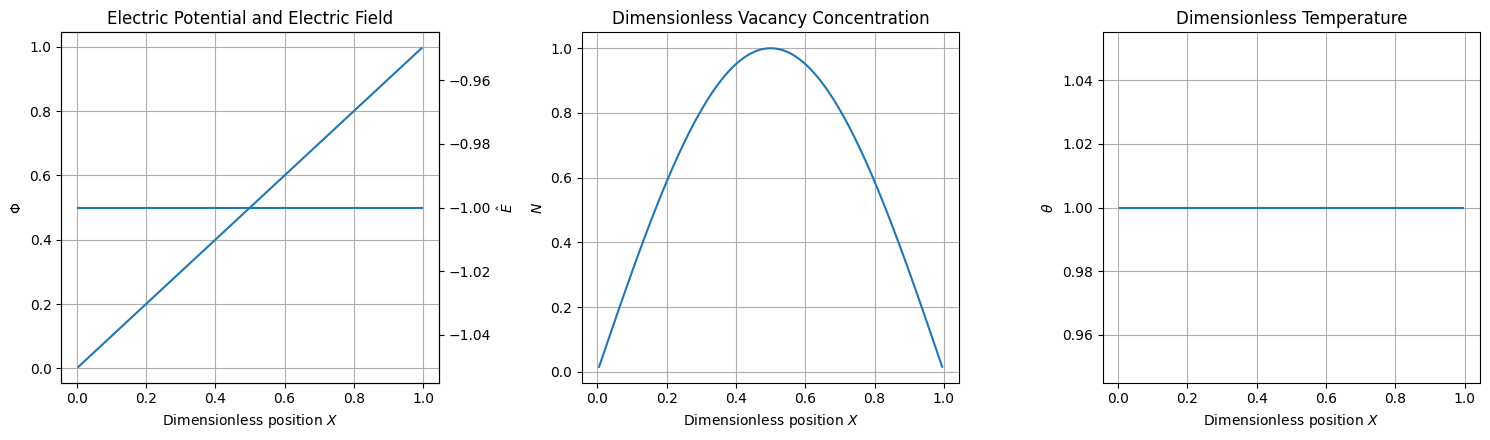

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ax1 = axes[0]
ax1.plot(X.value, Phi.value)
ax1.set_xlabel(r'Dimensionless position $X$')
ax1.set_ylabel(r'$\Phi$')
ax1.set_title('Electric Potential and Electric Field')
ax1.grid(True)

ax1_E = ax1.twinx()
E_clean = np.round(E_hat_final.value, decimals=6)
ax1_E.plot(X.value, E_clean)
ax1_E.set_ylabel(r'$\hat{E}$')
ax1_E.ticklabel_format(useOffset=False, style='plain')

for ax, y, ylabel, title in [(axes[1], N.value, r'$N$', 'Dimensionless Vacancy Concentration'), (axes[2], theta.value, r'$\theta$', 'Dimensionless Temperature')]:
    ax.plot(X.value, y)
    ax.set(xlabel=r'Dimensionless position $X$', ylabel=ylabel, title=title)
    ax.grid(True)
plt.tight_layout()
plt.show()

In [1]:
from fipy import (CellVariable, FaceVariable, Grid1D, DiffusionTerm, PowerLawConvectionTerm, ImplicitSourceTerm, TransientTerm, Viewer)
import numpy as np
import matplotlib.pyplot as plt

L = 1.0                    
nx = 100
dx = L / nx
max_sweeps = 100
coupling_tolerance = 1e-8
L_ref = 1.0e-8             
T_ref = 300.0
n_ref = 1.0e28
V_ref = 2.0
Vapp = 1.0                 
kB = 1.380649e-23          
q  = 1.602176634e-19       
a_hop = 3.2e-10            
f_esc = 1e12               
Ea_eV = 0.85 

Ea = Ea_eV * q             
D0 = 0.5 * a_hop**2 * f_esc        
t_ref = L_ref**2 / D0              
E_ref = V_ref / L_ref               
v_ref = D0 / L_ref                  
Gamma_a = Ea / (kB * T_ref)
chi_E = q * a_hop * E_ref / (2.0 * kB * T_ref)
T_op = 300.0
theta_op = T_op / T_ref
T0_room = 293.0
theta_room = T0_room / T_ref

params = {"L_ref": L_ref, "T_ref": T_ref, "n_ref": n_ref, "V_ref": V_ref, "D0": D0, "t_ref": t_ref, "E_ref": E_ref, "v_ref": v_ref, "Gamma_a": Gamma_a, "chi_E": chi_E, "theta_op": theta_op, "theta_room": theta_room}
for name, value in params.items():
    print(f"{name:<10} = {value:.4e}")

L_ref      = 1.0000e-08
T_ref      = 3.0000e+02
n_ref      = 1.0000e+28
V_ref      = 2.0000e+00
D0         = 5.1200e-08
t_ref      = 1.9531e-09
E_ref      = 2.0000e+08
v_ref      = 5.1200e+00
Gamma_a    = 3.2879e+01
chi_E      = 1.2378e+00
theta_op   = 1.0000e+00
theta_room = 9.7667e-01


In [6]:
mesh = Grid1D(nx=nx, dx=dx)
X = mesh.cellCenters[0]
Phi = CellVariable(name="Dimensionless Electric Potential", mesh=mesh, value=np.sin(np.pi * X), hasOld=True)
theta = CellVariable(name="Dimensionless Temperature", mesh=mesh, value=np.ones_like(X), hasOld=True)
N = CellVariable(name="Dimensionless Vacancy Concentration", mesh=mesh, value=np.sin(np.pi * X), hasOld=True)

theta.constrain(theta_op, mesh.facesLeft)
theta.constrain(theta_op, mesh.facesRight)

Phi.constrain(0.0, mesh.facesLeft)
Phi.constrain(Vapp, mesh.facesRight)

N.faceGrad.constrain((0.,), mesh.facesLeft)
N.faceGrad.constrain((0.,), mesh.facesRight)

D_hat_op = np.exp(-Gamma_a / theta_op)
v_hat_op = ((a_hop / L_ref) * D_hat_op * np.sinh(chi_E * Vapp / theta_op))
v_hat_over_D_hat = v_hat_op / D_hat_op

d = dx / 2.0
fluxCoeff = FaceVariable(mesh=mesh, rank=1, value=(v_hat_over_D_hat,))
fluxCoeff.setValue((2.0 * v_hat_over_D_hat / (1.0 + v_hat_over_D_hat * d),), where=mesh.facesLeft)
fluxCoeff.setValue((2.0 * v_hat_over_D_hat / (1.0 - v_hat_over_D_hat * d),), where=mesh.facesRight)

In [7]:
rho = 8200.0          
Cp  = 26.0            
k_ref = 58.0          
alpha_ref = k_ref / (rho * Cp)
alpha_ratio = alpha_ref / D0
lam_th = 0.1
Lambda_th = lam_th * T_ref
T0_room = 293.0
Gamma_H = (q * n_ref * V_ref / (rho * Cp * T_ref))

def S_hat_of_theta(theta_value):
    return -Gamma_a / theta_value**2

def D_hat_of_theta(theta_value):
    return np.exp(-Gamma_a / theta_value)

def v_hat_of_theta_E(theta_value, E_hat_value):
    return ((2.0 * L_ref / a_hop) * np.exp(-Gamma_a / theta_value) * np.sinh(chi_E * E_hat_value / theta_value))

def nD_cm3_of_N(N_value):
    return N_value * n_ref * 1.0e-6

sigma_ref = 1.0e5
nD_max_cm3 = 1.0e22
def sigma0_of_nD(nD_cm3):
    return np.interp(nD_cm3, [0.0, nD_max_cm3], [1.0, 1.0e5])

_nD_pts_cm3 = [0.0, 1.0e20, 5.0e21, 1.0e22]
_Eac_pts_eV = [0.20, 0.10, 0.00, -0.006]

def Eac_of_nD(nD_cm3):
    return np.interp(nD_cm3, _nD_pts_cm3, _Eac_pts_eV) * q

alpha_PF = 5.48e-4
beta_PF  = -5.70

def sigma_PF(E_Vcm, T_value):
    return np.exp(293.0 / T_value * (alpha_PF * np.sqrt(np.abs(E_Vcm)) + beta_PF))

def sigma_hat_of_N_theta_E(N_value, theta_value, E_hat_value):
    nD_cm3 = nD_cm3_of_N(N_value)
    T_value = T_ref * theta_value
    E_Vcm = np.abs(E_hat_value) * E_ref / 100.0
    sigma_arrhenius = (sigma0_of_nD(nD_cm3) * np.exp(-Eac_of_nD(nD_cm3) / (kB * T_value)))
    sigma_pf = sigma_PF(E_Vcm, T_value)
    return (sigma_arrhenius + sigma_pf) / sigma_ref

_nD_pts_kth_cm3 = [0.0, 1.0e22]
_kth0_pts = [0.0, 58.0]

def kth0_of_nD(nD_cm3):
    return np.interp(nD_cm3, _nD_pts_kth_cm3, _kth0_pts)

def k_hat_of_N_theta(N_value, theta_value):
    nD_cm3 = nD_cm3_of_N(N_value)
    kth0 = kth0_of_nD(nD_cm3)
    thermal_factor = (1.0 + Lambda_th * (theta_value - theta_room))
    return (kth0 / k_ref) * thermal_factor

D_hat_op = D_hat_of_theta(theta_op)
S_hat_op = S_hat_of_theta(theta_op)
E_hat_op = Vapp
v_hat_op = v_hat_of_theta_E(theta_op, E_hat_op)
sigma_hat_op = sigma_hat_of_N_theta_E(1.0, theta_op, E_hat_op)
k_hat_op = k_hat_of_N_theta(1.0, theta_op)

params = {"D_hat(theta_op)": D_hat_op, "S_hat(theta_op)": S_hat_op, "v_hat(theta_op,E_ref)": v_hat_op, "sigma_hat(N=1)": sigma_hat_op, "k_hat(N=1)": k_hat_op, "alpha_ref": alpha_ref, "alpha_ref / D0": alpha_ratio, "Gamma_H": Gamma_H, "Lambda_th": Lambda_th}
for name, value in params.items():
    print(f"{name:<23} = {value:.4e}")

D_hat(theta_op)         = 5.2557e-15
S_hat(theta_op)         = -3.2879e+01
v_hat(theta_op,E_ref)   = 5.1868e-13
sigma_hat(N=1)          = 1.2612e+00
k_hat(N=1)              = 1.7000e+00
alpha_ref               = 2.7205e-04
alpha_ref / D0          = 5.3134e+03
Gamma_H                 = 5.0099e+01
Lambda_th               = 3.0000e+01


In [ ]:
nx = 50
dtau = 1.0e-3
final_tau = 1.0
n_time_steps = int(final_tau / dtau)

Phi.setValue(1.0 - X)
theta.setValue(1.0)
N.setValue(np.sin(np.pi * X))

for time_step in range(n_time_steps):

    N.updateOld()
    theta.updateOld()
    
    converged = False

    for sweep in range(max_sweeps):

        Phi_iter = CellVariable(name="Phi iteration", mesh=mesh, value=Phi.value.copy())
        theta_iter = CellVariable(name="theta iteration", mesh=mesh, value=theta.value.copy())
        N_iter = CellVariable(name="N iteration", mesh=mesh, value=N.value.copy())

        E_hat_value = (-Phi_iter.grad[0]).value
        D_hat_value = D_hat_of_theta(theta_iter.value)
        S_hat_value = S_hat_of_theta(theta_iter.value)
        v_hat_value = v_hat_of_theta_E(theta_iter.value, E_hat_value)
        D_hat = CellVariable(name="D_hat", mesh=mesh, rank=0, value=D_hat_value)
        S_hat = CellVariable(name="S_hat", mesh=mesh, rank=0, value=S_hat_value)
        sigma_hat_value = sigma_hat_of_N_theta_E(N_iter.value, theta_iter.value, E_hat_value)
        sigma_hat = CellVariable(name="sigma_hat", mesh=mesh, rank=0, value=sigma_hat_value)
        electrical_eq = (DiffusionTerm(coeff=sigma_hat, var=Phi) == 0)
        electrical_eq.solve(var=Phi)

        E_hat_value = (-Phi.grad[0]).value
        v_hat_value = v_hat_of_theta_E(theta_iter.value, E_hat_value)
        E_hat_face = -Phi.faceGrad[0]
        theta_face = theta_iter.faceValue
        v_hat_face_value = v_hat_of_theta_E(theta_face.value, E_hat_face.value)
        v_hat = FaceVariable(name="v_hat", mesh=mesh, rank=1, value=(v_hat_face_value,))
        diffusion_term = DiffusionTerm(coeff=D_hat, var=N)
        drift_term = PowerLawConvectionTerm(coeff=v_hat, var=N)
        soret_coeff_value = (D_hat_value * S_hat_value * N_iter.value)
        soret_coeff = CellVariable(name="Soret coefficient", mesh=mesh, rank=0, value=soret_coeff_value)
        soret_term = DiffusionTerm(coeff=soret_coeff, var=theta)
        ambipolar_eq = (TransientTerm(var=N) == diffusion_term - drift_term + soret_term)
        ambipolar_eq.solve(var=N, dt=dtau)

        Jp_hat = (N.value * v_hat_value - D_hat_value * N.grad[0].value)
        heat_source_hat_value = (Gamma_H * Jp_hat * E_hat_value)
        heat_source_hat = CellVariable(name="Dimensionless Joule Heating Source", mesh=mesh, rank=0, value=heat_source_hat_value)
        k_hat_value = k_hat_of_N_theta(N_iter.value, theta_iter.value)
        k_hat_value = np.maximum(k_hat_value, 1.0e-10)
        k_hat = CellVariable(name="k_hat", mesh=mesh, rank=0, value=k_hat_value)
        heat_eq = (TransientTerm(var=theta) == DiffusionTerm(coeff=alpha_ratio * k_hat, var=theta) + heat_source_hat)
        heat_eq.solve(var=theta, dt=dtau)

        Phi_change = np.max(np.abs(Phi.value - Phi_iter.value))
        theta_change = np.max(np.abs(theta.value - theta_iter.value))
        N_change = np.max(np.abs(N.value - N_iter.value))
        max_change = max(Phi_change, theta_change, N_change)

        del Phi_iter
        del theta_iter
        del N_iter

        if max_change < coupling_tolerance:
            converged = True
            break

    if not converged:
        print(f"WARNING: coupling did not converge " f"at time step {time_step + 1}")
        print(f"Final coupling change = " f"{max_change:.4e}")
        break

print("Transient simulation finished.")
print(f"Final dimensionless time = " f"{(time_step + 1) * dtau:.4e}")
print(f"Final physical time = " f"{(time_step + 1) * dtau * t_ref:.4e} s")

Transient simulation finished.
Final dimensionless time = 1.0000e+00
Final physical time = 1.9531e-09 s


In [6]:
Phi_values = Phi.value.copy()
E_hat_values = Phi.grad[0]
E_hat_final = CellVariable(name="Dimensionless Electric Field", mesh=mesh, value=-E_hat_values)
dN_dX_final = N.grad[0]
D_hat_final = D_hat_of_theta(theta.value)
S_hat_final = S_hat_of_theta(theta.value)
v_hat_final = v_hat_of_theta_E(theta.value, E_hat_final.value)
Jp_hat_final = (N.value * v_hat_final - D_hat_final * dN_dX_final.value)
Q_hat_final = (Gamma_H * Jp_hat_final * E_hat_final.value)

results = {"Dimensionless electric potential (Phi)": Phi.value, "Dimensionless electric field (E_hat)": E_hat_final.value, "Dimensionless temperature (theta)": theta.value, "Dimensionless vacancy concentration (N)": N.value, "Dimensionless vacancy current (Jp_hat)": Jp_hat_final, "Dimensionless Joule heating (Q_hat)": Q_hat_final}
for name, data in results.items():
    print(f"{name}: " f"min = {np.min(data):.4e}, " f"max = {np.max(data):.4e}")

Dimensionless electric potential (Phi): min = 4.9988e-01, max = 5.0012e-01
Dimensionless electric field (E_hat): min = -4.9991e+01, max = -3.5134e-06
Dimensionless temperature (theta): min = 1.0000e+00, max = 1.0000e+00
Dimensionless vacancy concentration (N): min = -2.7083e-55, max = 9.9988e-01
Dimensionless vacancy current (Jp_hat): min = -2.0703e-14, max = 2.0533e-14
Dimensionless Joule heating (Q_hat): min = -3.1003e-11, max = 3.1003e-11


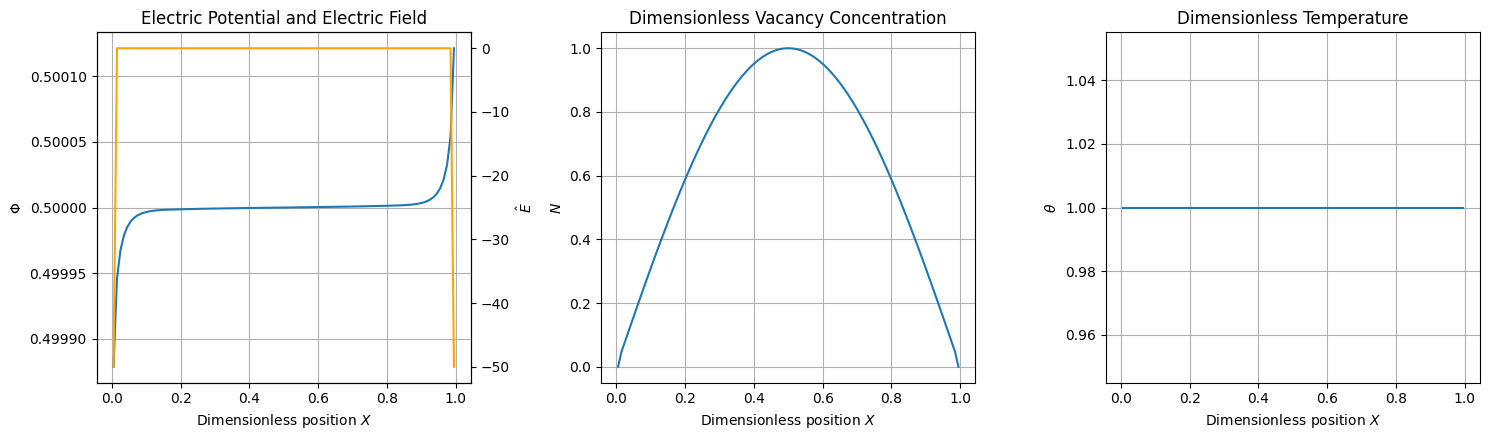

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ax1 = axes[0]
ax1.plot(X, Phi.value)
ax1.set_xlabel(r'Dimensionless position $X$')
ax1.set_ylabel(r'$\Phi$')
ax1.set_title('Electric Potential and Electric Field')
ax1.grid(True)
ax1_E = ax1.twinx()
ax1_E.plot(X, E_hat_final, color='orange')
ax1_E.set_ylabel(r'$\hat{E}$')
ax1_E.ticklabel_format(useOffset=False, style='plain')

for ax, y, ylabel, title in [(axes[1], N.value, r'$N$', 'Dimensionless Vacancy Concentration'), (axes[2], theta.value, r'$\theta$', 'Dimensionless Temperature')]:
    ax.plot(X, y)
    ax.set(xlabel=r'Dimensionless position $X$', ylabel=ylabel, title=title)
    ax.grid(True)
plt.tight_layout()
plt.show()

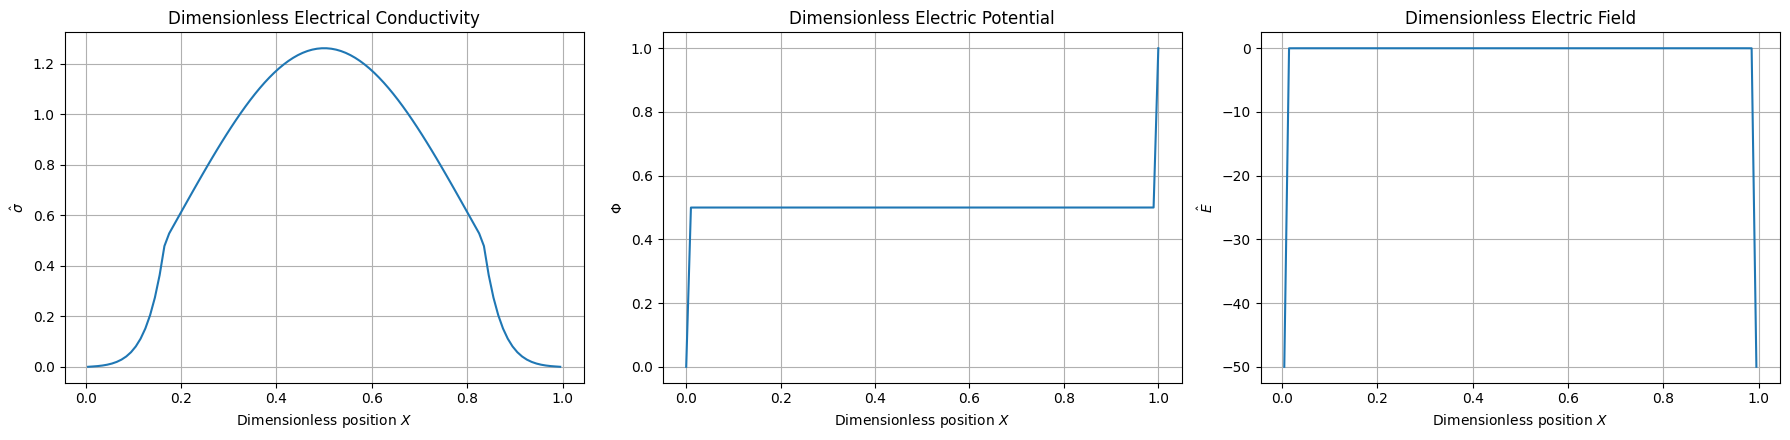

In [ ]:
sigma_final = sigma_hat_of_N_theta_E(N.value, theta.value, E_hat_final.value)
X_face = mesh.faceCenters[0].value
Phi_face = Phi.faceValue.value
X_cell = mesh.cellCenters[0].value
E_cell = -Phi.grad[0].value

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].plot(X, sigma_final)
axes[0].set_xlabel(r'Dimensionless position $X$')
axes[0].set_ylabel(r'$\hat{\sigma}$')
axes[0].set_title('Dimensionless Electrical Conductivity')
axes[0].grid(True)

axes[1].plot(X_face, Phi_face)
axes[1].set_xlabel(r'Dimensionless position $X$')
axes[1].set_ylabel(r'$\Phi$')
axes[1].set_title('Dimensionless Electric Potential')
axes[1].grid(True)

axes[2].plot(X_cell, E_cell)
axes[2].set_xlabel(r'Dimensionless position $X$')
axes[2].set_ylabel(r'$\hat{E}$')
axes[2].set_title('Dimensionless Electric Field')
axes[2].grid(True)
plt.tight_layout()
plt.show()

In [11]:
mesh_sizes = [25, 50, 100, 200]

dtau = 1.0e-3
final_tau = 1.0
n_time_steps = int(final_tau / dtau)

solutions = {}

for nx in mesh_sizes:

    print("\n" + "=" * 60)
    print(f"Running mesh convergence case: nx = {nx}")
    print("=" * 60)

    # --------------------------------------------------
    # Create mesh
    # --------------------------------------------------
    dx = L / nx
    mesh = Grid1D(nx=nx, dx=dx)
    X = mesh.cellCenters[0]

    # --------------------------------------------------
    # Create variables for THIS mesh
    # --------------------------------------------------
    Phi = CellVariable(
        name="Phi",
        mesh=mesh,
        value=np.sin(np.pi * X)
    )

    theta = CellVariable(
        name="theta",
        mesh=mesh,
        value=1.0,
        hasOld=True
    )

    N = CellVariable(
        name="N",
        mesh=mesh,
        value=np.sin(np.pi * X),
        hasOld=True
    )

    # ==================================================
    # Boundary Conditions
    # ==================================================

    # --------------------------------------------------
    # Temperature BC
    # theta = theta_op at both boundaries
    # --------------------------------------------------
    theta.constrain(
        theta_op,
        mesh.facesLeft
    )

    theta.constrain(
        theta_op,
        mesh.facesRight
    )

    # --------------------------------------------------
    # Electric potential BC
    # Phi = 0 at left
    # Phi = Vapp at right
    # --------------------------------------------------
    Phi.constrain(
        0.0,
        mesh.facesLeft
    )

    Phi.constrain(
        Vapp,
        mesh.facesRight
    )

    # --------------------------------------------------
    # Vacancy concentration BC
    # dN/dX = 0 at both boundaries
    # --------------------------------------------------
    N.faceGrad.constrain(
        (0.0,),
        mesh.facesLeft
    )

    N.faceGrad.constrain(
        (0.0,),
        mesh.facesRight
    )

    # ==================================================
    # Initial Conditions
    # ==================================================

    Phi.setValue(
        np.sin(np.pi * X)
    )

    theta.setValue(
        1.0
    )

    N.setValue(
        np.sin(np.pi * X)
    )

    # ==================================================
    # Transient simulation
    # ==================================================

    for time_step in range(n_time_steps):

        # ----------------------------------------------
        # Store previous time level
        # ----------------------------------------------
        N.updateOld()
        theta.updateOld()

        converged = False

        # ==================================================
        # Coupling iterations
        # ==================================================

        for sweep in range(max_sweeps):

            # ------------------------------------------
            # Previous coupling iteration
            # ------------------------------------------

            Phi_iter = CellVariable(
                name="Phi iteration",
                mesh=mesh,
                value=Phi.value.copy()
            )

            theta_iter = CellVariable(
                name="theta iteration",
                mesh=mesh,
                value=theta.value.copy()
            )

            N_iter = CellVariable(
                name="N iteration",
                mesh=mesh,
                value=N.value.copy()
            )

            # ------------------------------------------
            # Electric field
            # ------------------------------------------

            E_hat_value = (
                -Phi_iter.grad[0]
            ).value

            # ------------------------------------------
            # Transport coefficients
            # ------------------------------------------

            D_hat_value = D_hat_of_theta(
                theta_iter.value
            )

            S_hat_value = S_hat_of_theta(
                theta_iter.value
            )

            v_hat_value = v_hat_of_theta_E(
                theta_iter.value,
                E_hat_value
            )

            D_hat = CellVariable(
                name="D_hat",
                mesh=mesh,
                rank=0,
                value=D_hat_value
            )

            S_hat = CellVariable(
                name="S_hat",
                mesh=mesh,
                rank=0,
                value=S_hat_value
            )

            # ------------------------------------------
            # Electrical conductivity
            # ------------------------------------------

            sigma_hat_value = (
                sigma_hat_of_N_theta_E(
                    N_iter.value,
                    theta_iter.value,
                    E_hat_value
                )
            )

            sigma_hat = CellVariable(
                name="sigma_hat",
                mesh=mesh,
                rank=0,
                value=sigma_hat_value
            )

            # ------------------------------------------
            # Electrical equation
            # ------------------------------------------

            electrical_eq = (
                DiffusionTerm(
                    coeff=sigma_hat,
                    var=Phi
                ) == 0
            )

            electrical_eq.solve(
                var=Phi
            )

            # ------------------------------------------
            # Updated electric field
            # ------------------------------------------

            E_hat_value = (
                -Phi.grad[0]
            ).value

            v_hat_value = v_hat_of_theta_E(
                theta_iter.value,
                E_hat_value
            )

            # ------------------------------------------
            # Face velocity
            # ------------------------------------------

            E_hat_face = -Phi.faceGrad[0]

            theta_face = theta_iter.faceValue

            v_hat_face_value = (
                v_hat_of_theta_E(
                    theta_face.value,
                    E_hat_face.value
                )
            )

            v_hat = FaceVariable(
                name="v_hat",
                mesh=mesh,
                rank=1,
                value=(v_hat_face_value,)
            )

            # ------------------------------------------
            # Ambipolar transport
            # ------------------------------------------

            diffusion_term = DiffusionTerm(
                coeff=D_hat,
                var=N
            )

            drift_term = PowerLawConvectionTerm(
                coeff=v_hat,
                var=N
            )

            # ------------------------------------------
            # Soret term
            # ------------------------------------------

            soret_coeff_value = (
                D_hat_value
                * S_hat_value
                * N_iter.value
            )

            soret_coeff = CellVariable(
                name="Soret coefficient",
                mesh=mesh,
                rank=0,
                value=soret_coeff_value
            )

            soret_term = DiffusionTerm(
                coeff=soret_coeff,
                var=theta
            )

            # ------------------------------------------
            # Ambipolar equation
            # ------------------------------------------

            ambipolar_eq = (
                TransientTerm(var=N)
                ==
                diffusion_term
                - drift_term
                + soret_term
            )

            ambipolar_eq.solve(
                var=N,
                dt=dtau
            )

            # ------------------------------------------
            # Joule heating
            # ------------------------------------------

            Jp_hat = (
                N.value * v_hat_value
                - D_hat_value * N.grad[0].value
            )

            heat_source_hat_value = (
                Gamma_H
                * Jp_hat
                * E_hat_value
            )

            heat_source_hat = CellVariable(
                name="Dimensionless Joule Heating Source",
                mesh=mesh,
                rank=0,
                value=heat_source_hat_value
            )

            # ------------------------------------------
            # Thermal conductivity
            # ------------------------------------------

            k_hat_value = (
                k_hat_of_N_theta(
                    N_iter.value,
                    theta_iter.value
                )
            )

            k_hat_value = np.maximum(
                k_hat_value,
                1.0e-10
            )

            k_hat = CellVariable(
                name="k_hat",
                mesh=mesh,
                rank=0,
                value=k_hat_value
            )

            # ------------------------------------------
            # Heat equation
            # ------------------------------------------

            heat_eq = (
                TransientTerm(var=theta)
                ==
                DiffusionTerm(
                    coeff=alpha_ratio * k_hat,
                    var=theta
                )
                + heat_source_hat
            )

            heat_eq.solve(
                var=theta,
                dt=dtau
            )

            # ------------------------------------------
            # Coupling convergence
            # ------------------------------------------

            Phi_change = np.max(
                np.abs(
                    Phi.value
                    - Phi_iter.value
                )
            )

            theta_change = np.max(
                np.abs(
                    theta.value
                    - theta_iter.value
                )
            )

            N_change = np.max(
                np.abs(
                    N.value
                    - N_iter.value
                )
            )

            max_change = max(
                Phi_change,
                theta_change,
                N_change
            )

            # ------------------------------------------
            # Delete temporary variables
            # ------------------------------------------

            del Phi_iter
            del theta_iter
            del N_iter

            # ------------------------------------------
            # Check convergence
            # ------------------------------------------

            if max_change < coupling_tolerance:

                converged = True
                break

        # ==================================================
        # Check coupling convergence
        # ==================================================

        if not converged:

            print(
                f"WARNING: coupling did not converge "
                f"at time step {time_step + 1}"
            )

            print(
                f"Final coupling change = "
                f"{max_change:.4e}"
            )

            break

    # ==================================================
    # Final electric field
    # ==================================================

    E_hat_final = (
        -Phi.grad[0]
    ).value

    # ==================================================
    # Store solution
    # ==================================================

    solutions[nx] = {

        "X": X.value.copy(),

        "Phi": Phi.value.copy(),

        "E": E_hat_final.copy(),

        "N": N.value.copy(),

        "theta": theta.value.copy()
    }

    # ==================================================
    # Print results
    # ==================================================

    print("Simulation finished.")

    print(
        f"Final dimensionless time = "
        f"{(time_step + 1) * dtau:.4e}"
    )

    print(
        f"Final physical time = "
        f"{(time_step + 1) * dtau * t_ref:.4e} s"
    )

print("\n" + "=" * 60)
print("Mesh convergence simulations completed.")
print("=" * 60)


Running mesh convergence case: nx = 25
Simulation finished.
Final dimensionless time = 1.0000e+00
Final physical time = 1.9531e-09 s

Running mesh convergence case: nx = 50
Simulation finished.
Final dimensionless time = 1.0000e+00
Final physical time = 1.9531e-09 s

Running mesh convergence case: nx = 100
Simulation finished.
Final dimensionless time = 1.0000e+00
Final physical time = 1.9531e-09 s

Running mesh convergence case: nx = 200


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\fipy\terms\powerLawConvectionTerm.py:72: RuntimeWarning: overflow encountered in multiply
  alpha = numerix.where(  (10. >= P) & (P > eps),  ((P-1.) + tmpSqr*tmpSqr*tmp) / P, alpha)
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\fipy\terms\powerLawConvectionTerm.py:76: RuntimeWarning: overflow encountered in multiply
  alpha = numerix.where((-eps >  P) & (P >= -10.),     (tmpSqr*tmpSqr*tmp - 1.) / P, alpha)


Simulation finished.
Final dimensionless time = 1.0000e+00
Final physical time = 1.9531e-09 s

Mesh convergence simulations completed.


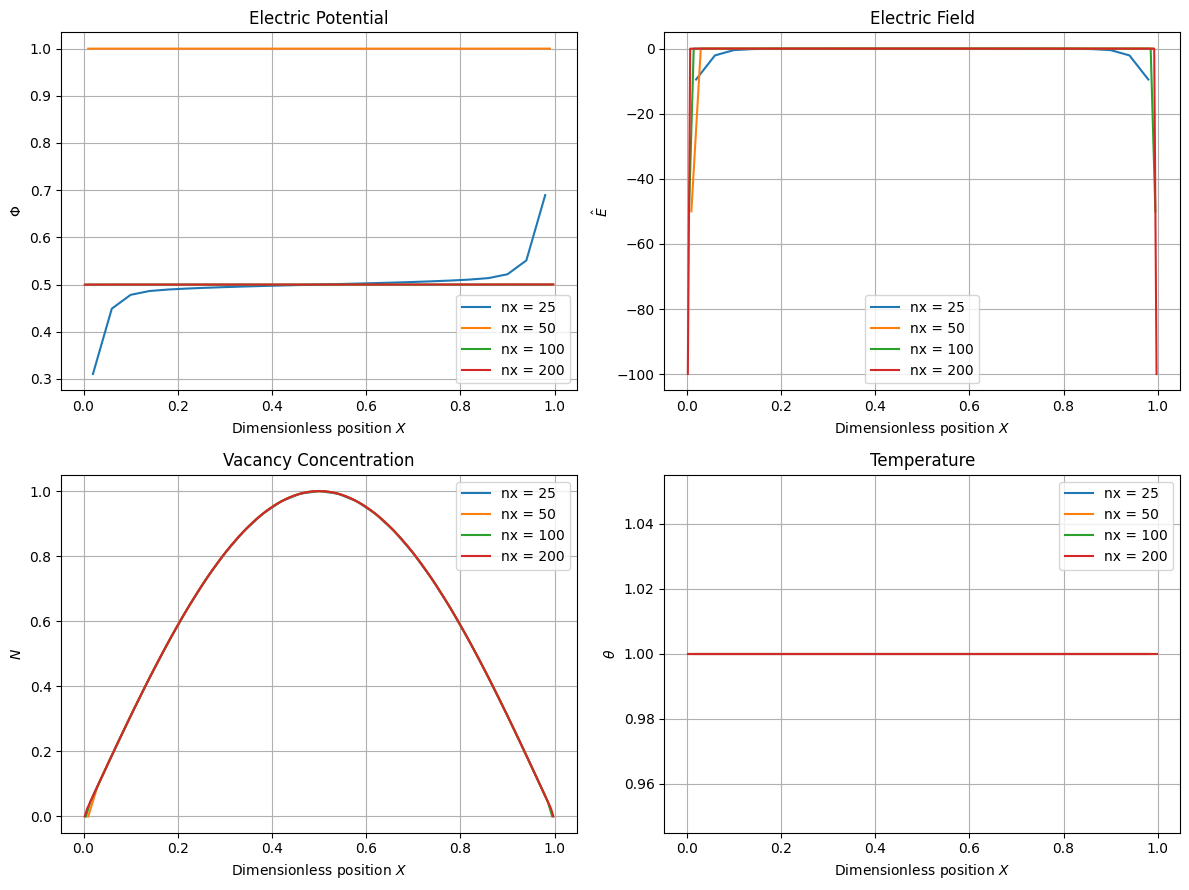

In [13]:
# ============================================================
# Mesh Convergence: Plot Final Solutions
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# ------------------------------------------------------------
# 1. Electric Potential
# ------------------------------------------------------------

ax = axes[0, 0]

for nx in mesh_sizes:
    ax.plot(
        solutions[nx]["X"],
        solutions[nx]["Phi"],
        label=f"nx = {nx}"
    )

ax.set_xlabel(r"Dimensionless position $X$")
ax.set_ylabel(r"$\Phi$")
ax.set_title("Electric Potential")
ax.grid(True)
ax.legend()


# ------------------------------------------------------------
# 2. Electric Field
# ------------------------------------------------------------

ax = axes[0, 1]

for nx in mesh_sizes:
    ax.plot(
        solutions[nx]["X"],
        solutions[nx]["E"],
        label=f"nx = {nx}"
    )

ax.set_xlabel(r"Dimensionless position $X$")
ax.set_ylabel(r"$\hat{E}$")
ax.set_title("Electric Field")
ax.grid(True)
ax.legend()


# ------------------------------------------------------------
# 3. Vacancy Concentration
# ------------------------------------------------------------

ax = axes[1, 0]

for nx in mesh_sizes:
    ax.plot(
        solutions[nx]["X"],
        solutions[nx]["N"],
        label=f"nx = {nx}"
    )

ax.set_xlabel(r"Dimensionless position $X$")
ax.set_ylabel(r"$N$")
ax.set_title("Vacancy Concentration")
ax.grid(True)
ax.legend()


# ------------------------------------------------------------
# 4. Temperature
# ------------------------------------------------------------

ax = axes[1, 1]

for nx in mesh_sizes:
    ax.plot(
        solutions[nx]["X"],
        solutions[nx]["theta"],
        label=f"nx = {nx}"
    )

ax.set_xlabel(r"Dimensionless position $X$")
ax.set_ylabel(r"$\theta$")
ax.set_title("Temperature")
ax.grid(True)
ax.legend()


plt.tight_layout()
plt.show()

In [14]:
for nx in mesh_sizes:
    print(f"\n===== nx = {nx} =====")
    
    Phi_val = solutions[nx]["Phi"]
    E_val = solutions[nx]["E"]
    N_val = solutions[nx]["N"]
    theta_val = solutions[nx]["theta"]

    sigma_val = sigma_hat_of_N_theta_E(
        N_val,
        theta_val,
        E_val
    )

    print(f"Phi   : min = {np.min(Phi_val):.4e}, max = {np.max(Phi_val):.4e}")
    print(f"E     : min = {np.min(E_val):.4e}, max = {np.max(E_val):.4e}")
    print(f"N     : min = {np.min(N_val):.4e}, max = {np.max(N_val):.4e}")
    print(f"theta : min = {np.min(theta_val):.4e}, max = {np.max(theta_val):.4e}")
    print(f"sigma : min = {np.min(sigma_val):.4e}, max = {np.max(sigma_val):.4e}")
    print(f"sigma finite? {np.all(np.isfinite(sigma_val))}")


===== nx = 25 =====
Phi   : min = 3.1053e-01, max = 6.8947e-01
E     : min = -9.4926e+00, max = -2.4651e-02
N     : min = 6.2791e-02, max = 1.0000e+00
theta : min = 1.0000e+00, max = 1.0000e+00
sigma : min = 1.9912e-03, max = 1.2612e+00
sigma finite? True

===== nx = 50 =====
Phi   : min = 9.9981e-01, max = 9.9994e-01
E     : min = -4.9992e+01, max = -3.5718e-06
N     : min = 2.7019e-55, max = 9.9951e-01
theta : min = 1.0000e+00, max = 1.0000e+00
sigma : min = 8.0672e-06, max = 1.2603e+00
sigma finite? True

===== nx = 100 =====
Phi   : min = 4.9988e-01, max = 5.0012e-01
E     : min = -4.9991e+01, max = -3.5134e-06
N     : min = -2.7083e-55, max = 9.9988e-01
theta : min = 1.0000e+00, max = 1.0000e+00
sigma : min = 8.0671e-06, max = 1.2610e+00
sigma finite? True

===== nx = 200 =====
Phi   : min = 4.9963e-01, max = 5.0037e-01
E     : min = -9.9944e+01, max = -7.3767e-06
N     : min = -5.4805e-109, max = 9.9997e-01
theta : min = 1.0000e+00, max = 1.0000e+00
sigma : min = 7.3890e-05, max

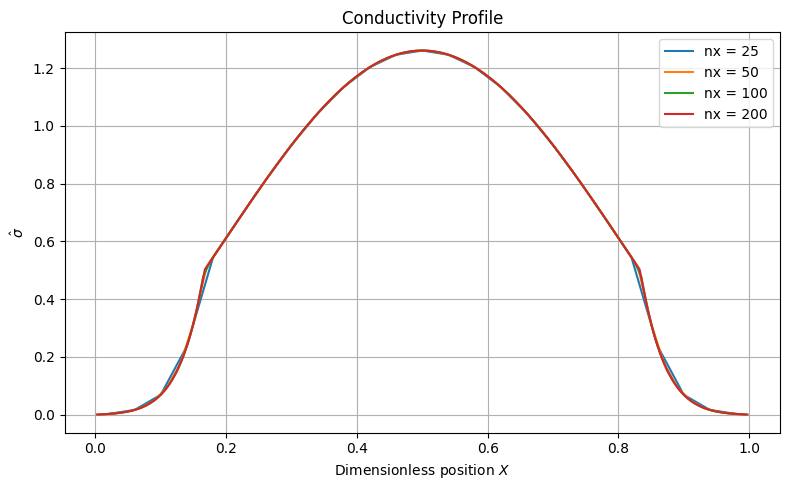

In [15]:
# ============================================================
# Conductivity profile for mesh convergence study
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

for nx in mesh_sizes:

    X_val = solutions[nx]["X"]
    N_val = solutions[nx]["N"]
    theta_val = solutions[nx]["theta"]
    E_val = solutions[nx]["E"]

    sigma_val = sigma_hat_of_N_theta_E(
        N_val,
        theta_val,
        E_val
    )

    ax.plot(X_val, sigma_val, label=f"nx = {nx}")

ax.set_xlabel(r"Dimensionless position $X$")
ax.set_ylabel(r"$\hat{\sigma}$")
ax.set_title("Conductivity Profile")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

In [16]:
for nx in mesh_sizes:
    Phi = solutions[nx]["Phi"]
    sigma_val = sigma_hat_of_N_theta_E(
        solutions[nx]["N"],
        solutions[nx]["theta"],
        solutions[nx]["E"]
    )

    print(f"\nnx = {nx}")
    print(f"Phi left  = {Phi[0]:.8e}")
    print(f"Phi right = {Phi[-1]:.8e}")
    print(f"sigma left  = {sigma_val[0]:.8e}")
    print(f"sigma right = {sigma_val[-1]:.8e}")


nx = 25
Phi left  = 3.10529741e-01
Phi right = 6.89470259e-01
sigma left  = 1.99116291e-03
sigma right = 1.99116291e-03

nx = 50
Phi left  = 9.99806908e-01
Phi right = 9.99942186e-01
sigma left  = 8.06719700e-06
sigma right = 7.77523874e-04

nx = 100
Phi left  = 4.99878816e-01
Phi right = 5.00121162e-01
sigma left  = 8.06707420e-06
sigma right = 8.06707515e-06

nx = 200
Phi left  = 4.99634473e-01
Phi right = 5.00365512e-01
sigma left  = 7.38901015e-05
sigma right = 7.38901103e-05


In [17]:
# ============================================================
# Quantitative mesh convergence: nx = 100 vs nx = 200
# ============================================================

X100 = solutions[100]["X"]
X200 = solutions[200]["X"]

# Interpolate nx = 200 solution onto nx = 100 locations
Phi200_interp = np.interp(X100, X200, solutions[200]["Phi"])
N200_interp = np.interp(X100, X200, solutions[200]["N"])
theta200_interp = np.interp(X100, X200, solutions[200]["theta"])

# Differences
Phi_diff = np.abs(solutions[100]["Phi"] - Phi200_interp)
N_diff = np.abs(solutions[100]["N"] - N200_interp)
theta_diff = np.abs(solutions[100]["theta"] - theta200_interp)

print("Mesh convergence: nx = 100 vs nx = 200")
print("------------------------------------------")
print(f"Max |Phi_100 - Phi_200|   = {np.max(Phi_diff):.6e}")
print(f"Max |N_100 - N_200|       = {np.max(N_diff):.6e}")
print(f"Max |theta_100 - theta_200| = {np.max(theta_diff):.6e}")

Mesh convergence: nx = 100 vs nx = 200
------------------------------------------
Max |Phi_100 - Phi_200|   = 1.595137e-04
Max |N_100 - N_200|       = 1.177988e-02
Max |theta_100 - theta_200| = 0.000000e+00


In [18]:
# ============================================================
# Quantitative mesh convergence: nx = 50 vs nx = 100
# ============================================================

X50 = solutions[50]["X"]
X100 = solutions[100]["X"]

Phi100_interp = np.interp(X50, X100, solutions[100]["Phi"])
N100_interp = np.interp(X50, X100, solutions[100]["N"])
theta100_interp = np.interp(X50, X100, solutions[100]["theta"])

Phi_diff = np.abs(solutions[50]["Phi"] - Phi100_interp)
N_diff = np.abs(solutions[50]["N"] - N100_interp)
theta_diff = np.abs(solutions[50]["theta"] - theta100_interp)

print("Mesh convergence: nx = 50 vs nx = 100")
print("------------------------------------------")
print(f"Max |Phi_50 - Phi_100|     = {np.max(Phi_diff):.6e}")
print(f"Max |N_50 - N_100|         = {np.max(N_diff):.6e}")
print(f"Max |theta_50 - theta_100| = {np.max(theta_diff):.6e}")

Mesh convergence: nx = 50 vs nx = 100
------------------------------------------
Max |Phi_50 - Phi_100|     = 4.998945e-01
Max |N_50 - N_100|         = 2.355323e-02
Max |theta_50 - theta_100| = 0.000000e+00


In [20]:
# ============================================================
# TIME-STEP CONVERGENCE STUDY
# Fixed mesh: nx = 100
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Fixed mesh and simulation parameters
# ------------------------------------------------------------

nx = 100
L = 1.0

# Time steps to test
dtau_values = [1.0e-2, 5.0e-3, 1.0e-3, 5.0e-4]

final_tau = 1.0

# Store final solutions
time_solutions = {}

# ------------------------------------------------------------
# Run simulations
# ------------------------------------------------------------

for dtau in dtau_values:

    print("\n" + "=" * 60)
    print(f"Running time convergence case: dtau = {dtau:.1e}")
    print("=" * 60)

    # Number of time steps
    n_time_steps = int(final_tau / dtau)

    # --------------------------------------------------------
    # Create fresh mesh
    # --------------------------------------------------------

    mesh = Grid1D(nx=nx, Lx=L)
    X = mesh.cellCenters[0]

    # --------------------------------------------------------
    # Create fresh variables
    # --------------------------------------------------------

    Phi = CellVariable(
        name="Dimensionless Electric Potential",
        mesh=mesh,
        value=0.0
    )

    theta = CellVariable(
        name="Dimensionless Temperature",
        mesh=mesh,
        value=1.0,
        hasOld=True
    )

    N = CellVariable(
        name="Dimensionless Vacancy Concentration",
        mesh=mesh,
        value=0.0,
        hasOld=True
    )

    # --------------------------------------------------------
    # Boundary conditions
    # --------------------------------------------------------

    # Temperature: fixed temperature at both ends
    theta.constrain(theta_op, mesh.facesLeft)
    theta.constrain(theta_op, mesh.facesRight)

    # Electric potential
    Phi.constrain(0.0, mesh.facesLeft)
    Phi.constrain(Vapp, mesh.facesRight)

    # Vacancy: zero flux at both ends
    N.faceGrad.constrain((0.0,), mesh.facesLeft)
    N.faceGrad.constrain((0.0,), mesh.facesRight)

    # --------------------------------------------------------
    # Initial conditions
    # --------------------------------------------------------

    Phi.setValue(np.sin(np.pi * X.value))
    theta.setValue(1.0)
    N.setValue(np.sin(np.pi * X.value))

    # --------------------------------------------------------
    # Transient simulation
    # --------------------------------------------------------

    for time_step in range(n_time_steps):

        # Store previous time-step values
        N.updateOld()
        theta.updateOld()

        converged = False

        # ----------------------------------------------------
        # Coupling iterations
        # ----------------------------------------------------

        for sweep in range(max_sweeps):

            # Store previous coupling iteration
            Phi_iter = CellVariable(
                name="Phi iteration",
                mesh=mesh,
                value=Phi.value.copy()
            )

            theta_iter = CellVariable(
                name="theta iteration",
                mesh=mesh,
                value=theta.value.copy()
            )

            N_iter = CellVariable(
                name="N iteration",
                mesh=mesh,
                value=N.value.copy()
            )

            # ------------------------------------------------
            # ELECTRICAL PROBLEM
            # ------------------------------------------------

            E_hat_value = (-Phi_iter.grad[0]).value

            D_hat_value = D_hat_of_theta(theta_iter.value)

            S_hat_value = S_hat_of_theta(theta_iter.value)

            v_hat_value = v_hat_of_theta_E(
                theta_iter.value,
                E_hat_value
            )

            D_hat = CellVariable(
                name="D_hat",
                mesh=mesh,
                rank=0,
                value=D_hat_value
            )

            S_hat = CellVariable(
                name="S_hat",
                mesh=mesh,
                rank=0,
                value=S_hat_value
            )

            sigma_hat_value = sigma_hat_of_N_theta_E(
                N_iter.value,
                theta_iter.value,
                E_hat_value
            )

            sigma_hat = CellVariable(
                name="sigma_hat",
                mesh=mesh,
                rank=0,
                value=sigma_hat_value
            )

            electrical_eq = (
                DiffusionTerm(
                    coeff=sigma_hat,
                    var=Phi
                ) == 0
            )

            electrical_eq.solve(var=Phi)

            # ------------------------------------------------
            # ELECTRIC FIELD
            # ------------------------------------------------

            E_hat_value = (-Phi.grad[0]).value

            v_hat_value = v_hat_of_theta_E(
                theta_iter.value,
                E_hat_value
            )

            E_hat_face = -Phi.faceGrad[0]

            theta_face = theta_iter.faceValue

            v_hat_face_value = v_hat_of_theta_E(
                theta_face.value,
                E_hat_face.value
            )

            v_hat = FaceVariable(
                name="v_hat",
                mesh=mesh,
                rank=1,
                value=(v_hat_face_value,)
            )

            # ------------------------------------------------
            # AMBIPOLAR / VACANCY EQUATION
            # ------------------------------------------------

            diffusion_term = DiffusionTerm(
                coeff=D_hat,
                var=N
            )

            drift_term = PowerLawConvectionTerm(
                coeff=v_hat,
                var=N
            )

            soret_coeff_value = (
                D_hat_value *
                S_hat_value *
                N_iter.value
            )

            soret_coeff = CellVariable(
                name="Soret coefficient",
                mesh=mesh,
                rank=0,
                value=soret_coeff_value
            )

            soret_term = DiffusionTerm(
                coeff=soret_coeff,
                var=theta
            )

            ambipolar_eq = (
                TransientTerm(var=N)
                ==
                diffusion_term
                - drift_term
                + soret_term
            )

            ambipolar_eq.solve(
                var=N,
                dt=dtau
            )

            # ------------------------------------------------
            # HEAT EQUATION
            # ------------------------------------------------

            Jp_hat = (
                N.value * v_hat_value
                - D_hat_value * N.grad[0].value
            )

            heat_source_hat_value = (
                Gamma_H *
                Jp_hat *
                E_hat_value
            )

            heat_source_hat = CellVariable(
                name="Dimensionless Joule Heating Source",
                mesh=mesh,
                rank=0,
                value=heat_source_hat_value
            )

            k_hat_value = k_hat_of_N_theta(
                N_iter.value,
                theta_iter.value
            )

            k_hat_value = np.maximum(
                k_hat_value,
                1.0e-10
            )

            k_hat = CellVariable(
                name="k_hat",
                mesh=mesh,
                rank=0,
                value=k_hat_value
            )

            heat_eq = (
                TransientTerm(var=theta)
                ==
                DiffusionTerm(
                    coeff=alpha_ratio * k_hat,
                    var=theta
                )
                + heat_source_hat
            )

            heat_eq.solve(
                var=theta,
                dt=dtau
            )

            # ------------------------------------------------
            # COUPLING CONVERGENCE
            # ------------------------------------------------

            Phi_change = np.max(
                np.abs(Phi.value - Phi_iter.value)
            )

            theta_change = np.max(
                np.abs(theta.value - theta_iter.value)
            )

            N_change = np.max(
                np.abs(N.value - N_iter.value)
            )

            max_change = max(
                Phi_change,
                theta_change,
                N_change
            )

            # Delete temporary variables
            del Phi_iter
            del theta_iter
            del N_iter

            if max_change < coupling_tolerance:
                converged = True
                break

        # ----------------------------------------------------
        # Check coupling convergence
        # ----------------------------------------------------

        if not converged:

            print(
                f"WARNING: coupling did not converge "
                f"at time step {time_step + 1}"
            )

            print(
                f"Final coupling change = "
                f"{max_change:.4e}"
            )

            break

    # --------------------------------------------------------
    # Store final solution
    # --------------------------------------------------------

    time_solutions[dtau] = {
        "X": X.value.copy(),
        "Phi": Phi.value.copy(),
        "E": (-Phi.grad[0]).value.copy(),
        "N": N.value.copy(),
        "theta": theta.value.copy()
    }

    print(
        f"Simulation finished. "
        f"Final dimensionless time = "
        f"{(time_step + 1) * dtau:.4e}"
    )

    print(
        f"Final physical time = "
        f"{(time_step + 1) * dtau * t_ref:.4e} s"
    )

print("\n" + "=" * 60)
print("Time-step convergence simulations completed.")
print("=" * 60)


Running time convergence case: dtau = 1.0e-02
Simulation finished. Final dimensionless time = 1.0000e+00
Final physical time = 1.9531e-09 s

Running time convergence case: dtau = 5.0e-03
Simulation finished. Final dimensionless time = 1.0000e+00
Final physical time = 1.9531e-09 s

Running time convergence case: dtau = 1.0e-03
Simulation finished. Final dimensionless time = 1.0000e+00
Final physical time = 1.9531e-09 s

Running time convergence case: dtau = 5.0e-04
Simulation finished. Final dimensionless time = 1.0000e+00
Final physical time = 1.9531e-09 s

Time-step convergence simulations completed.


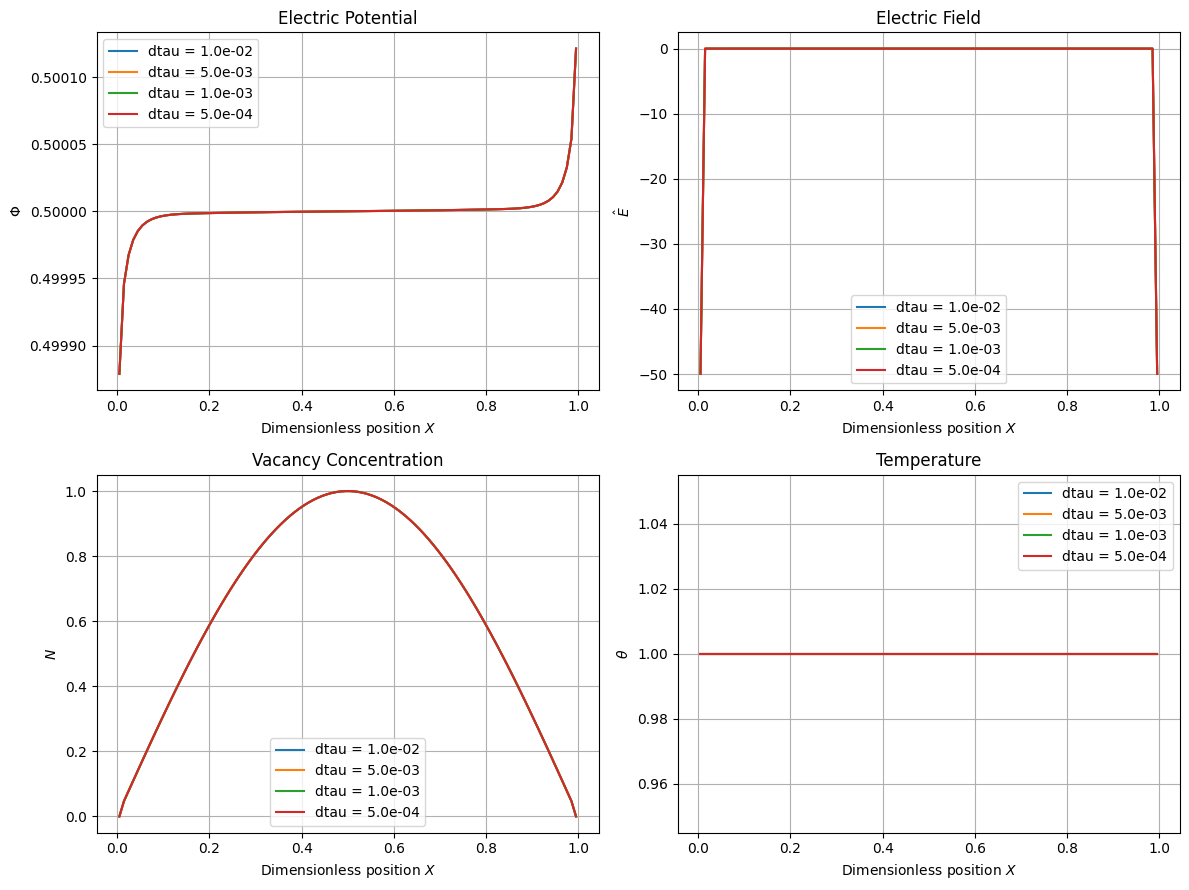

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Electric Potential
ax = axes[0, 0]
for dtau in dtau_values:
    ax.plot(
        time_solutions[dtau]["X"],
        time_solutions[dtau]["Phi"],
        label=f"dtau = {dtau:.1e}"
    )
ax.set_xlabel(r"Dimensionless position $X$")
ax.set_ylabel(r"$\Phi$")
ax.set_title("Electric Potential")
ax.grid(True)
ax.legend()

# Electric Field
ax = axes[0, 1]
for dtau in dtau_values:
    ax.plot(
        time_solutions[dtau]["X"],
        time_solutions[dtau]["E"],
        label=f"dtau = {dtau:.1e}"
    )
ax.set_xlabel(r"Dimensionless position $X$")
ax.set_ylabel(r"$\hat{E}$")
ax.set_title("Electric Field")
ax.grid(True)
ax.legend()

# Vacancy Concentration
ax = axes[1, 0]
for dtau in dtau_values:
    ax.plot(
        time_solutions[dtau]["X"],
        time_solutions[dtau]["N"],
        label=f"dtau = {dtau:.1e}"
    )
ax.set_xlabel(r"Dimensionless position $X$")
ax.set_ylabel(r"$N$")
ax.set_title("Vacancy Concentration")
ax.grid(True)
ax.legend()

# Temperature
ax = axes[1, 1]
for dtau in dtau_values:
    ax.plot(
        time_solutions[dtau]["X"],
        time_solutions[dtau]["theta"],
        label=f"dtau = {dtau:.1e}"
    )
ax.set_xlabel(r"Dimensionless position $X$")
ax.set_ylabel(r"$\theta$")
ax.set_title("Temperature")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()